# Examen Aplicado de Machine Learning I

**Predicción del volumen de tráfico horario en la autopista Interestatal 94, Minneapolis**

Esteban Molina Almazabal
Ingeniería en Inteligencia Artificial, Universidad Mayor

Este notebook desarrolla un problema de regresión completo: selección y declaración del
dataset, análisis exploratorio, preprocesamiento sin fuga de información, reducción de
dimensionalidad con PCA, segmentación con K-Means, modelamiento supervisado con
validación cruzada e interpretación de los resultados. Cada sección indica el punto de
la ficha de examen al que responde.

---

### 1. Selección del dataset

| Campo | Valor |
|---|---|
| Nombre | Metro Interstate Traffic Volume |
| Fuente | UCI Machine Learning Repository, dataset 492 |
| URL | https://archive.ics.uci.edu/dataset/492/metro+interstate+traffic+volume |
| Descarga directa | https://archive.ics.uci.edu/static/public/492/metro+interstate+traffic+volume.zip |
| Observaciones | 48.204 |
| Variables | 9 |
| Variable objetivo | `traffic_volume`, vehículos por hora |
| Tipo de tarea | Regresión |
| Licencia | Creative Commons Attribution 4.0 |

Los datos provienen de la estación de conteo ATR 301 de la autopista I-94 en dirección
oeste, entre Minneapolis y St. Paul. Cada fila corresponde a una hora e informa cuántos
vehículos circularon, junto con las condiciones meteorológicas de esa hora y si el día
era feriado. El período cubierto va de octubre de 2012 a septiembre de 2018.

El dataset cumple con holgura los mínimos exigidos, ya que tiene 48.204 observaciones
frente a las 500 requeridas y 8 predictores frente a los 6 requeridos, y no pertenece a
la lista de conjuntos excluidos. Se escogió además porque presenta problemas de calidad
de datos reales, como registros duplicados, valores físicamente imposibles y una
categoría mal codificada, lo que permite justificar las decisiones de preprocesamiento
con evidencia concreta.

In [1]:
# Interruptor de entorno: True para ejecutar en un equipo local, False para Colab con Google Drive
EJECUCION_LOCAL = True

if EJECUCION_LOCAL:
    DATA_PATH = r"data/raw/Metro_Interstate_Traffic_Volume.csv"
else:
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_PATH = "/content/drive/MyDrive/AI/DATASET/Metro_Interstate_Traffic_Volume.csv"

import os
print(os.path.exists(DATA_PATH), round(os.path.getsize(DATA_PATH) / 1e6, 2), "MB")

True 3.24 MB


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
warnings.filterwarnings('ignore')

# 1. Fijar la semilla para garantizar reproducibilidad en todas las etapas
SEED = 42
np.random.seed(SEED)

# 2. Crear la carpeta donde se guardan todas las figuras del informe
os.makedirs('figures', exist_ok=True)

# 3. Configuración común de los gráficos
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 60)

# 4. Paleta usada de forma consistente en todo el notebook
AZUL, ROJO, VERDE = '#2a6f97', '#c1121f', '#588157'

# 5. La lectura por defecto convierte el texto "None" de la columna holiday en NaN.
# Se cargan las dos versiones para dejar el problema a la vista en el punto 2.
df_ingenuo = pd.read_csv(DATA_PATH)
df = pd.read_csv(DATA_PATH, keep_default_na=False, na_values=[''])

filas, columnas = df.shape
print(f"Número exacto de observaciones (filas): {filas}")
print(f"Número exacto de variables (columnas): {columnas}")
df.head()

Número exacto de observaciones (filas): 48204
Número exacto de variables (columnas): 9


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,None,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,None,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,None,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,None,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,None,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


### 2. Análisis Exploratorio de Datos (EDA)

**Dimensiones y tipos de variables**

El dataset original tiene 48.204 observaciones y 9 variables. De ellas, 4 son numéricas
(`temp`, `rain_1h`, `snow_1h` y `clouds_all`), 3 son categóricas de texto (`holiday`,
`weather_main` y `weather_description`), 1 es la marca temporal (`date_time`) y la
restante es la variable objetivo (`traffic_volume`).

In [3]:
print("Tipos de variables:")
print(df.dtypes)
print("\nConteo por tipo:")
print(df.dtypes.value_counts())

Tipos de variables:
holiday                    str
temp                   float64
rain_1h                float64
snow_1h                float64
clouds_all               int64
weather_main               str
weather_description        str
date_time                  str
traffic_volume           int64
dtype: object

Conteo por tipo:
str        4
float64    3
int64      2
Name: count, dtype: int64


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              48204 non-null  str    
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  str    
 6   weather_description  48204 non-null  str    
 7   date_time            48204 non-null  str    
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), str(4)
memory usage: 5.1 MB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
temp,48204.0,281.205870,13.338232,0.0,272.16,282.45,291.806,310.07
rain_1h,48204.0,0.334264,44.789133,0.0,0.00,0.00,0.000,9831.30
snow_1h,48204.0,0.000222,0.008168,0.0,0.00,0.00,0.000,0.51
clouds_all,48204.0,49.362231,39.015750,0.0,1.00,64.00,90.000,100.00
traffic_volume,48204.0,3259.818355,1986.860670,0.0,1193.00,3380.00,4933.000,7280.00


**Análisis de valores faltantes**

Este es el primer hallazgo relevante del EDA. La lectura por defecto de pandas reporta
**48.143 valores faltantes en `holiday`**, es decir un 99,87% de la columna, lo que
llevaría a descartarla de inmediato. Sin embargo, esos nulos no existen: la columna usa
el texto literal `"None"` para indicar que la hora no corresponde a un feriado, y pandas
lo confunde con un marcador de ausencia. Leyendo el archivo con
`keep_default_na=False`, el dataset **no tiene ningún valor faltante**.

Existe sí un problema distinto en esa misma columna. Solo 61 de las 48.204 horas están
marcadas como feriado, cuando un feriado abarca 24 horas y deberían ser cerca de 1.400.
La razón es que la fuente marca el feriado únicamente en el registro de las 00:00 de
cada día y deja el resto de las horas como `"None"`. La variable, tal como viene, es
engañosa, y se reconstruye en el punto 3.

In [6]:
# 1. Comparar el porcentaje de nulos que reporta cada forma de lectura
comparacion_nulos = pd.DataFrame({
    'nulos_lectura_por_defecto': df_ingenuo.isnull().sum(),
    'pct_lectura_por_defecto': (df_ingenuo.isnull().mean() * 100).round(2),
    'nulos_lectura_correcta': df.isnull().sum(),
    'pct_lectura_correcta': (df.isnull().mean() * 100).round(2),
})
print(comparacion_nulos)
print(f"\nTotal de nulos con la lectura por defecto: {df_ingenuo.isnull().sum().sum()}")
print(f"Total de nulos con la lectura correcta   : {df.isnull().sum().sum()}")

                     nulos_lectura_por_defecto  pct_lectura_por_defecto  nulos_lectura_correcta  pct_lectura_correcta
holiday                                  48143                    99.87                       0                   0.0
temp                                         0                     0.00                       0                   0.0
rain_1h                                      0                     0.00                       0                   0.0
snow_1h                                      0                     0.00                       0                   0.0
clouds_all                                   0                     0.00                       0                   0.0
weather_main                                 0                     0.00                       0                   0.0
weather_description                          0                     0.00                       0                   0.0
date_time                                    0          

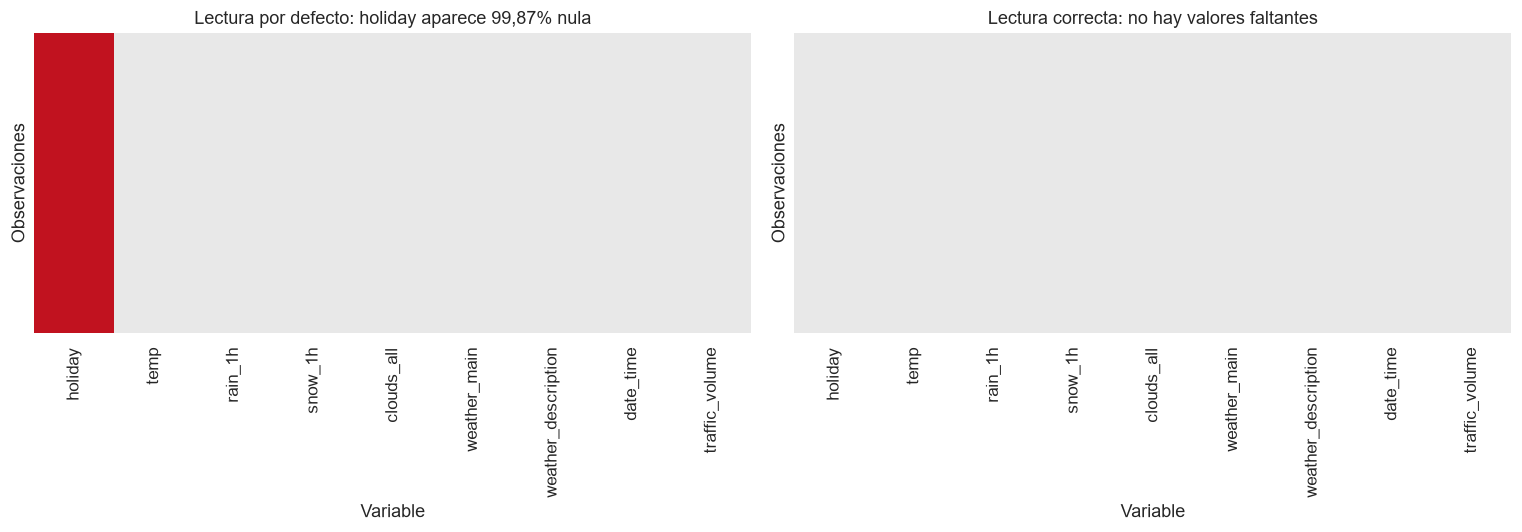

Valores de la columna holiday:
holiday
None                         48143
Labor Day                        7
Thanksgiving Day                 6
Christmas Day                    6
New Years Day                    6
Martin Luther King Jr Day        6
Columbus Day                     5
Veterans Day                     5
Washingtons Birthday             5
Memorial Day                     5
Independence Day                 5
State Fair                       5
Name: count, dtype: int64


In [7]:
# 2. Visualizar ambos mapas de calor de nulos para dejar en evidencia el artefacto
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(df_ingenuo.isnull(), cbar=False, yticklabels=False,
            cmap=['#e8e8e8', ROJO], ax=ax[0])
ax[0].set_title('Lectura por defecto: holiday aparece 99,87% nula')
ax[0].set_xlabel('Variable')
ax[0].set_ylabel('Observaciones')

sns.heatmap(df.isnull(), cbar=False, yticklabels=False,
            cmap=['#e8e8e8', ROJO], ax=ax[1])
ax[1].set_title('Lectura correcta: no hay valores faltantes')
ax[1].set_xlabel('Variable')
ax[1].set_ylabel('Observaciones')

plt.tight_layout()
plt.savefig('figures/fig01_heatmap_nulos.png', dpi=150, bbox_inches='tight')
plt.show()

# 3. Revisar los valores reales de holiday
print("Valores de la columna holiday:")
print(df['holiday'].value_counts())

**Decisión sobre los valores faltantes**

No se imputa ni se elimina ninguna columna, porque no hay datos faltantes que tratar. La
decisión correcta es de lectura del archivo, no de imputación. En el punto 3 sí se
corrige la codificación defectuosa de `holiday`, transformándola en una variable binaria
y reconstruyendo la marca para las 24 horas de cada día feriado a partir de la fecha.

**Registros duplicados**

El segundo hallazgo de calidad de datos son 7.629 marcas temporales repetidas. Al
inspeccionarlas se observa que la hora y el volumen de tráfico coinciden, y lo que
cambia es la descripción del clima: cuando en una misma hora se registró más de una
condición meteorológica, por ejemplo niebla y llovizna simultáneas, la fuente escribió
una fila por condición. Se trata de una duplicación de la dimensión meteorológica y no
de una medición nueva de tráfico.

Conservarlas sería un error grave, porque la misma hora entraría varias veces al
entrenamiento y podría además quedar repartida entre train y test, filtrando el valor
objetivo hacia el conjunto de entrenamiento. Se conserva el primer registro de cada
hora, quedando **40.575 observaciones**.

In [8]:
# 1. Convertir la marca temporal a formato de fecha
df['date_time'] = pd.to_datetime(df['date_time'])

print(f"Filas: {len(df)}")
print(f"Marcas temporales únicas: {df['date_time'].nunique()}")
print(f"Marcas temporales duplicadas: {df['date_time'].duplicated().sum()}")

# 2. Mostrar un ejemplo del patrón de duplicación
ejemplo = df[df['date_time'].duplicated(keep=False)].head(6)
print("\nEjemplo: misma hora y mismo tráfico, distinta descripción del clima")
print(ejemplo[['date_time', 'weather_main', 'weather_description', 'traffic_volume']].to_string(index=False))

Filas: 48204
Marcas temporales únicas: 40575
Marcas temporales duplicadas: 7629

Ejemplo: misma hora y mismo tráfico, distinta descripción del clima
          date_time weather_main     weather_description  traffic_volume
2012-10-10 07:00:00         Rain              light rain            6793
2012-10-10 07:00:00      Drizzle light intensity drizzle            6793
2012-10-10 08:00:00         Rain              light rain            6283
2012-10-10 08:00:00      Drizzle light intensity drizzle            6283
2012-10-10 09:00:00         Rain              light rain            5680
2012-10-10 09:00:00      Drizzle light intensity drizzle            5680


In [9]:
# 3. Conservar el primer registro de cada hora
filas_antes = len(df)
df = (df.drop_duplicates(subset='date_time', keep='first')
        .sort_values('date_time')
        .reset_index(drop=True))
print(f"Deduplicación: de {filas_antes} a {len(df)} filas, se eliminan {filas_antes - len(df)}")

# 4. Normalizar el texto de weather_description, donde 'sky is clear' y 'Sky is Clear'
# venían como dos niveles distintos por diferencia de mayúsculas
niveles_antes = df['weather_description'].nunique()
df['weather_description'] = df['weather_description'].str.lower().str.strip()
print(f"weather_description: de {niveles_antes} a {df['weather_description'].nunique()} niveles")
print(f"weather_main: {df['weather_main'].nunique()} niveles")

Deduplicación: de 48204 a 40575 filas, se eliminan 7629
weather_description: de 35 a 34 niveles
weather_main: 11 niveles


**Análisis de la variable objetivo**

La distribución de `traffic_volume` tiene una asimetría de **-0,107**, muy por debajo del
umbral de 1,0 que justificaría una transformación logarítmica, de modo que **no se
transforma**. Aplicar el logaritmo sería además contraproducente, ya que empeora la
asimetría hasta -1,49 al comprimir la cola alta, que es donde se concentra la mayor
parte de los datos.

Lo relevante está en la curtosis de **-1,30**. Un valor tan negativo, junto con la forma
del histograma, revela que la distribución es **bimodal**: existe un grupo de horas con
tráfico casi nulo, correspondiente a la madrugada, y otro con tráfico alto y sostenido
durante el día, con muy pocas horas intermedias. El problema no es la asimetría sino que
hay dos regímenes de operación mezclados, algo que ninguna transformación logarítmica
puede corregir.

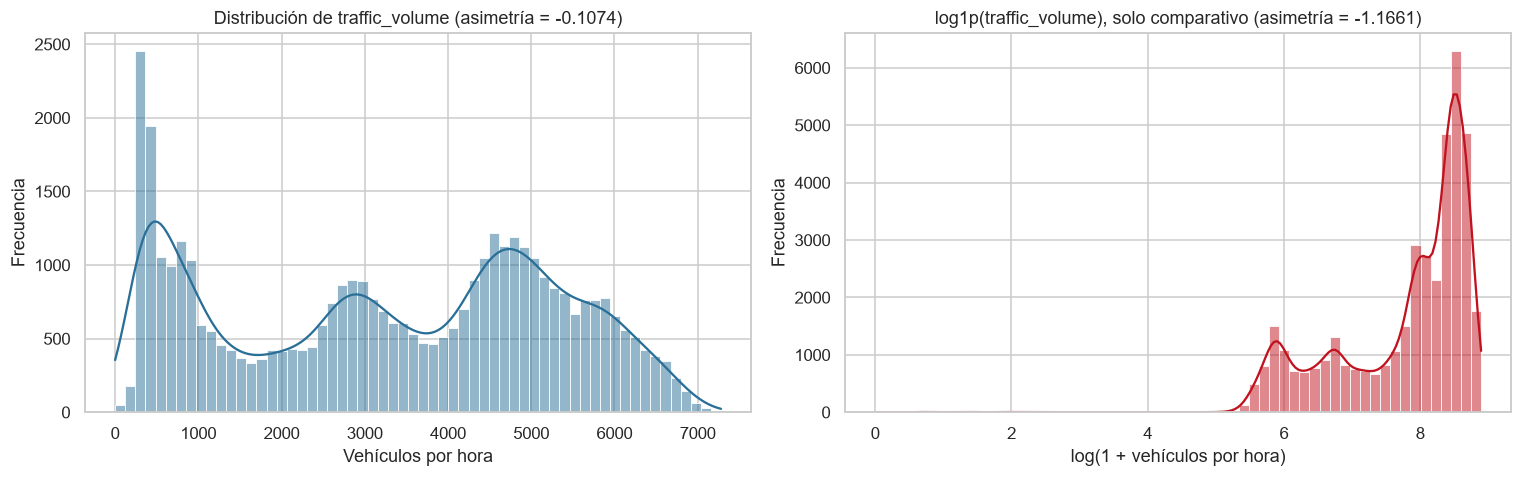

Asimetría: -0.1074
Curtosis : -1.2967
Asimetría tras aplicar log1p: -1.1661


In [10]:
from scipy import stats

# 1. Calcular asimetría y curtosis de la variable objetivo
y_all = df['traffic_volume']
asimetria = stats.skew(y_all)
curtosis = stats.kurtosis(y_all)
asimetria_log = stats.skew(np.log1p(y_all))

# 2. Comparar la distribución original con la transformación logarítmica
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
sns.histplot(y_all, kde=True, bins=60, color=AZUL, ax=ax[0])
ax[0].set_title(f'Distribución de traffic_volume (asimetría = {asimetria:.4f})')
ax[0].set_xlabel('Vehículos por hora')
ax[0].set_ylabel('Frecuencia')

sns.histplot(np.log1p(y_all), kde=True, bins=60, color=ROJO, ax=ax[1])
ax[1].set_title(f'log1p(traffic_volume), solo comparativo (asimetría = {asimetria_log:.4f})')
ax[1].set_xlabel('log(1 + vehículos por hora)')
ax[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.savefig('figures/fig02_distribucion_objetivo.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Asimetría: {asimetria:.4f}")
print(f"Curtosis : {curtosis:.4f}")
print(f"Asimetría tras aplicar log1p: {asimetria_log:.4f}")

**Detección de outliers**

El criterio del rango intercuartílico marca una cantidad importante de valores como
atípicos, pero es necesario distinguir entre valores extremos que son reales y valores
que son físicamente imposibles.

Se **mantienen** los siguientes casos. `rain_1h` y `snow_1h` son cero cerca del 99% del
tiempo, de modo que el criterio IQR marca como atípica cualquier precipitación, lo que
es un artefacto de una distribución con exceso de ceros y no un error: que llueva 5 mm
es un dato válido. `clouds_all` va de 0 a 100 por definición, ya que es un porcentaje.
`traffic_volume` es la variable objetivo y su rango de 0 a 7.280 vehículos es plausible
para una autopista interestatal, además de que eliminar sus extremos sesgaría el modelo
hacia las horas de menor carga.

Se **corrigen** en cambio dos casos imposibles. Diez registros tienen `temp` igual a 0
Kelvin, es decir el cero absoluto o -273,15 °C, algo inviable en Minneapolis y atribuible
a una falla del sensor. Un registro tiene `rain_1h` igual a 9.831,3 mm en una hora,
cuando el récord mundial en ese lapso es de unos 305 mm.

Estas 11 filas, que representan el 0,03% del total, se marcan como `NaN` en lugar de
eliminarse, ya que el resto de sus variables es válido y el tráfico de esas horas sigue
siendo información útil. La imputación se realiza dentro del pipeline con la mediana
calculada solo sobre el conjunto de entrenamiento, que es la diferencia entre imputar
correctamente e imputar filtrando información del test.

In [11]:
# 1. Resumir el criterio IQR sobre las variables numéricas
def resumen_iqr(datos, columnas):
    filas_resumen = []
    for c in columnas:
        q1, q3 = datos[c].quantile([0.25, 0.75])
        iqr = q3 - q1
        limite_inf, limite_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        fuera = ((datos[c] < limite_inf) | (datos[c] > limite_sup)).sum()
        filas_resumen.append({'variable': c, 'Q1': q1, 'Q3': q3, 'IQR': iqr,
                              'limite_inf': limite_inf, 'limite_sup': limite_sup,
                              'n_outliers': int(fuera),
                              'pct_outliers': round(100 * fuera / len(datos), 2),
                              'min': datos[c].min(), 'max': datos[c].max()})
    return pd.DataFrame(filas_resumen)

cols_num = ['temp', 'rain_1h', 'snow_1h', 'clouds_all', 'traffic_volume']
print(resumen_iqr(df, cols_num).round(3).to_string(index=False))

      variable      Q1      Q3     IQR  limite_inf  limite_sup  n_outliers  pct_outliers  min     max
          temp  271.84  292.28   20.44      241.18      322.94          10          0.02  0.0  310.07
       rain_1h    0.00    0.00    0.00        0.00        0.00        2054          5.06  0.0 9831.30
       snow_1h    0.00    0.00    0.00        0.00        0.00          31          0.08  0.0    0.51
    clouds_all    1.00   90.00   89.00     -132.50      223.50           0          0.00  0.0  100.00
traffic_volume 1248.50 4952.00 3703.50    -4306.75    10507.25           0          0.00  0.0 7280.00


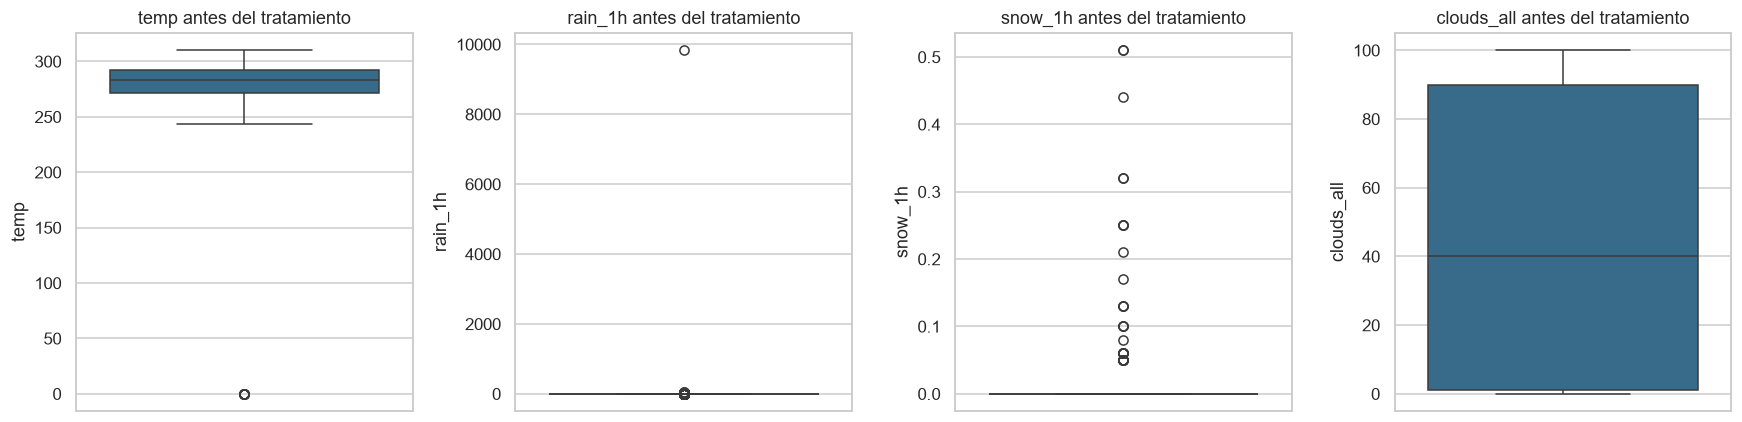

Registros con temp = 0 Kelvin (cero absoluto): 10
Registros con rain_1h > 500 mm en una hora  : 1

Los tres valores más altos de rain_1h:
          date_time  rain_1h weather_main  traffic_volume
2016-07-11 17:00:00  9831.30         Rain            5535
2013-08-07 02:00:00    55.63         Rain             315
2013-06-24 11:00:00    44.45         Rain            4802


In [12]:
# 2. Boxplots antes del tratamiento
fig, ax = plt.subplots(1, 4, figsize=(16, 4))
for i, c in enumerate(['temp', 'rain_1h', 'snow_1h', 'clouds_all']):
    sns.boxplot(y=df[c], ax=ax[i], color=AZUL)
    ax[i].set_title(f'{c} antes del tratamiento')
    ax[i].set_ylabel(c)
plt.tight_layout()
plt.savefig('figures/fig03_boxplots_antes.png', dpi=150, bbox_inches='tight')
plt.show()

# 3. Cuantificar los casos físicamente imposibles
print(f"Registros con temp = 0 Kelvin (cero absoluto): {int((df['temp'] < 200).sum())}")
print(f"Registros con rain_1h > 500 mm en una hora  : {int((df['rain_1h'] > 500).sum())}")
print("\nLos tres valores más altos de rain_1h:")
print(df.nlargest(3, 'rain_1h')[['date_time', 'rain_1h', 'weather_main', 'traffic_volume']].to_string(index=False))

In [13]:
# 4. Marcar como NaN solo los valores imposibles, para que los impute el pipeline
n_temp = int((df['temp'] < 200).sum())
df.loc[df['temp'] < 200, 'temp'] = np.nan
n_rain = int((df['rain_1h'] > 500).sum())
df.loc[df['rain_1h'] > 500, 'rain_1h'] = np.nan
print(f"Registros de temp marcados como NaN   : {n_temp}")
print(f"Registros de rain_1h marcados como NaN: {n_rain}")

# 5. Convertir la temperatura de Kelvin a Celsius para que los coeficientes
# y las importancias del modelo sean interpretables
df['temp'] = df['temp'] - 273.15
print("\nTemperatura en grados Celsius:")
print(df['temp'].describe().round(2))

Registros de temp marcados como NaN   : 10
Registros de rain_1h marcados como NaN: 1

Temperatura en grados Celsius:
count    40565.00
mean         8.24
std         13.09
min        -29.76
25%         -1.30
50%          9.72
75%         19.13
max         36.92
Name: temp, dtype: float64


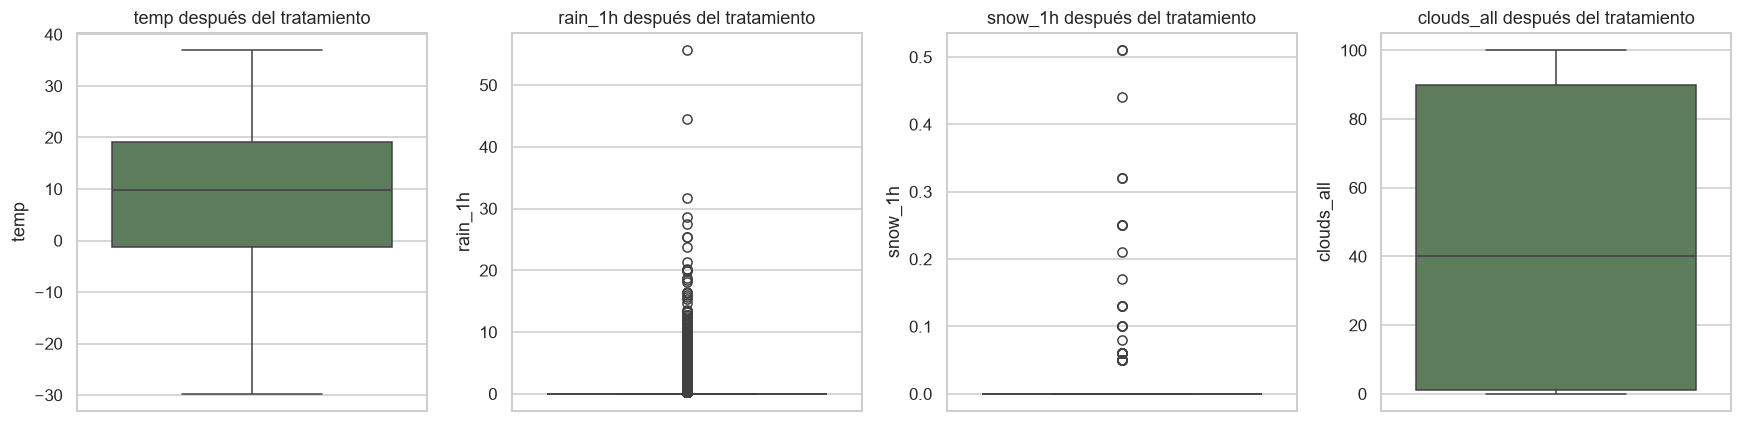

In [14]:
# 6. Boxplots después del tratamiento
fig, ax = plt.subplots(1, 4, figsize=(16, 4))
for i, c in enumerate(['temp', 'rain_1h', 'snow_1h', 'clouds_all']):
    sns.boxplot(y=df[c], ax=ax[i], color=VERDE)
    ax[i].set_title(f'{c} después del tratamiento')
    ax[i].set_ylabel(c)
plt.tight_layout()
plt.savefig('figures/fig04_boxplots_despues.png', dpi=150, bbox_inches='tight')
plt.show()

### 3. Preprocesamiento y Feature Engineering

**3.1 Ingeniería de variables temporales**

Este paso es el que decide el resultado del trabajo. Las variables meteorológicas
correlacionan muy débilmente con el tráfico, ya que `temp` alcanza apenas 0,139 y
`rain_1h` se queda en -0,013, mientras que el volumen medio pasa de **373 vehículos a
las 3 de la madrugada a 5.709 a las 16 horas**. La señal está concentrada en el tiempo,
y viene encapsulada dentro de `date_time`, que como texto resulta inutilizable para
cualquier modelo.

Se construyen cinco variables nuevas: `hour`, `weekday` y `month` extraídas directamente
de la marca temporal, `is_weekend` derivada del día de la semana, e `is_holiday`, que
reconstruye la marca de feriado para las 24 horas del día correspondiente y corrige así
el defecto de codificación detectado en el punto 2. Con esa reconstrucción las horas
identificadas como feriado suben de 61 a 1.437.

In [15]:
# 1. Extraer las componentes temporales que contienen la señal del fenómeno
df['hour'] = df['date_time'].dt.hour
df['weekday'] = df['date_time'].dt.dayofweek          # 0 = lunes, 6 = domingo
df['month'] = df['date_time'].dt.month
df['is_weekend'] = (df['weekday'] >= 5).astype(int)

# 2. Reconstruir la marca de feriado para las 24 horas del día, corrigiendo el
# defecto detectado en el punto 2, donde solo venía marcada la hora 00:00
feriados_antes = int((df['holiday'] != 'None').sum())
fechas_feriado = set(df.loc[df['holiday'] != 'None', 'date_time'].dt.date)
df['is_holiday'] = df['date_time'].dt.date.isin(fechas_feriado).astype(int)

print(f"Horas marcadas como feriado antes de reconstruir : {feriados_antes}")
print(f"Horas marcadas como feriado después de reconstruir: {int(df['is_holiday'].sum())}")
print(f"Días feriado distintos: {len(fechas_feriado)}")
df[['date_time', 'hour', 'weekday', 'month', 'is_weekend', 'is_holiday', 'traffic_volume']].head()

Horas marcadas como feriado antes de reconstruir : 53
Horas marcadas como feriado después de reconstruir: 1203
Días feriado distintos: 53


,date_time,hour,weekday,month,is_weekend,is_holiday,traffic_volume
0,2012-10-02 09:00:00,9,1,10,0,0,5545
1,2012-10-02 10:00:00,10,1,10,0,0,4516
2,2012-10-02 11:00:00,11,1,10,0,0,4767
3,2012-10-02 12:00:00,12,1,10,0,0,5026
4,2012-10-02 13:00:00,13,1,10,0,0,4918


In [16]:
# 3. Definir los grupos de variables según el tratamiento que recibirá cada una
CONTINUAS = ['temp', 'rain_1h', 'snow_1h', 'clouds_all']
ORDINALES = ['hour', 'weekday', 'month']
NOMINALES = ['weather_main', 'weather_description', 'is_weekend', 'is_holiday']
PREDICTORAS = CONTINUAS + ORDINALES + NOMINALES
OBJETIVO = 'traffic_volume'

print(f"Numéricas continuas ({len(CONTINUAS)}): {CONTINUAS}")
print(f"Ordinales ({len(ORDINALES)}): {ORDINALES}")
print(f"Nominales ({len(NOMINALES)}): {NOMINALES}")
print(f"\nTotal de predictoras: {len(PREDICTORAS)}, la ficha exige al menos 6")
print(f"Numéricas continuas : {len(CONTINUAS)}, la ficha exige al menos 3")
print(f"Observaciones       : {len(df)}, la ficha exige al menos 500")

Numéricas continuas (4): ['temp', 'rain_1h', 'snow_1h', 'clouds_all']
Ordinales (3): ['hour', 'weekday', 'month']
Nominales (4): ['weather_main', 'weather_description', 'is_weekend', 'is_holiday']

Total de predictoras: 11, la ficha exige al menos 6
Numéricas continuas : 4, la ficha exige al menos 3
Observaciones       : 40575, la ficha exige al menos 500


**3.2 Correlaciones y multicolinealidad**

El mapa de calor de correlaciones de Pearson entrega valores bajos en todos los casos.
Las cinco variables más correlacionadas con el objetivo son `hour` (0,355),
`is_weekend` (-0,213), `weekday` (-0,145), `temp` (0,139) y `clouds_all` (0,078).

Conviene leer estos números con cuidado, porque **ninguna correlación alcanza siquiera
0,36 y eso no significa que no exista señal**. El coeficiente de Pearson mide asociación
lineal, y la relación entre la hora y el tráfico es marcadamente no lineal, ya que sube
hasta las 16 horas y luego desciende. Pearson subestima de forma severa la importancia
real de `hour`, que en el punto 5 resultará ser la variable dominante por amplio margen.
El clima, por su parte, casi no explica el tráfico: las personas se desplazan a trabajar
independientemente de la lluvia.

Respecto de la multicolinealidad, **ningún par de predictores supera el umbral de
r > 0,85**. El par más alto es `is_weekend` con `weekday`, en 0,789, lo que es esperable
porque la primera se deriva de la segunda. Ambas se conservan, ya que codifican matices
distintos: `weekday` distingue un lunes de un viernes, mientras que `is_weekend` marca el
corte laboral. Se deja constancia de esta redundancia parcial, que corresponde
justamente al escenario para el que se diseñó la penalización L2 de Ridge.

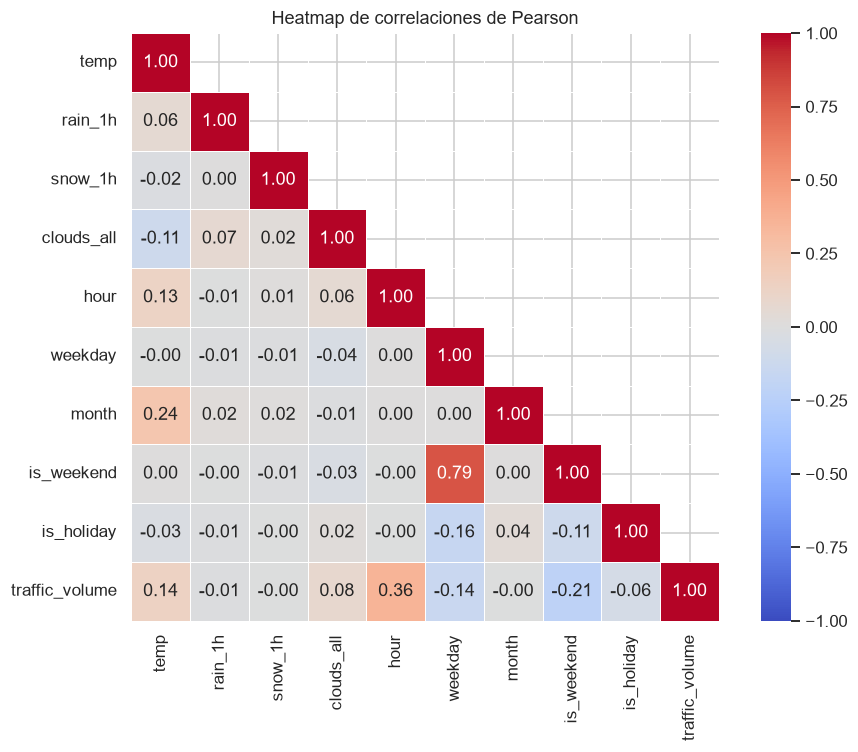

In [17]:
# 1. Matriz de correlación de Pearson sobre las variables numéricas
cols_corr = CONTINUAS + ORDINALES + ['is_weekend', 'is_holiday', OBJETIVO]
matriz_corr = df[cols_corr].corr(numeric_only=True)

plt.figure(figsize=(9, 7))
mascara = np.triu(np.ones_like(matriz_corr, dtype=bool), k=1)
sns.heatmap(matriz_corr, mask=mascara, annot=True, cmap='coolwarm', fmt='.2f',
            vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title('Heatmap de correlaciones de Pearson')
plt.tight_layout()
plt.savefig('figures/fig05_heatmap_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# 2. Identificar las cinco variables más correlacionadas con la variable objetivo
corr_objetivo = matriz_corr[OBJETIVO].drop(OBJETIVO).sort_values(key=np.abs, ascending=False)
print("Top 5 variables más correlacionadas con traffic_volume:")
print(pd.DataFrame({'correlacion': corr_objetivo.head(5).round(4),
                    'valor_absoluto': corr_objetivo.head(5).abs().round(4)}))

# 3. Buscar automáticamente pares de predictores con multicolinealidad
corr_pred = df[CONTINUAS + ORDINALES + ['is_weekend', 'is_holiday']].corr(numeric_only=True).abs()
valores = corr_pred.to_numpy().copy()          # pandas 3.0 entrega arreglos de solo lectura
np.fill_diagonal(valores, 0)
corr_pred = pd.DataFrame(valores, index=corr_pred.index, columns=corr_pred.columns)
pares = (corr_pred.where(np.triu(np.ones(corr_pred.shape, dtype=bool), k=1))
         .stack().sort_values(ascending=False))

print("\nPares de predictores más correlacionados entre sí:")
print(pares.head(6).round(4))

alta_corr = pares[pares > 0.85]
print(f"\nPares con r > 0.85 (posible multicolinealidad): {len(alta_corr)}")
if alta_corr.empty:
    print("No se encontraron pares que superen el umbral.")
else:
    print(alta_corr.round(4))

Top 5 variables más correlacionadas con traffic_volume:
            correlacion  valor_absoluto
hour             0.3552          0.3552
is_weekend      -0.2125          0.2125
weekday         -0.1445          0.1445
temp             0.1393          0.1393
clouds_all       0.0784          0.0784

Pares de predictores más correlacionados entre sí:
weekday     is_weekend    0.7894
temp        month         0.2404
weekday     is_holiday    0.1597
temp        hour          0.1286
is_weekend  is_holiday    0.1106
temp        clouds_all    0.1098
dtype: float64

Pares con r > 0.85 (posible multicolinealidad): 0
No se encontraron pares que superen el umbral.


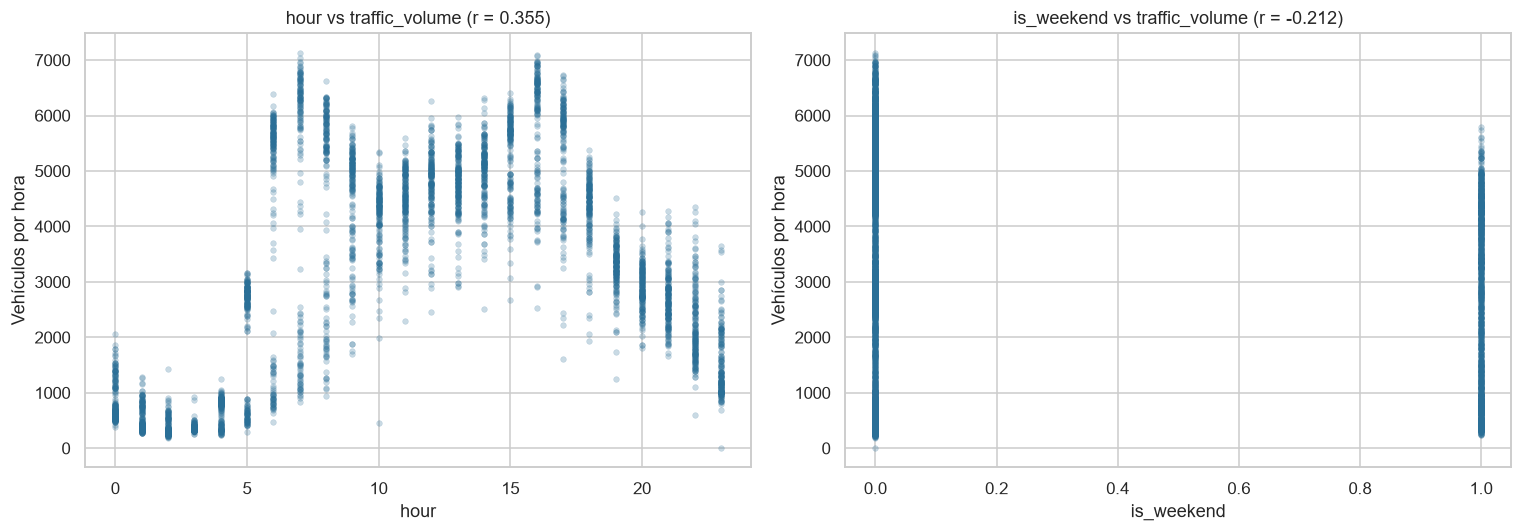

In [19]:
# 4. Dispersión de las dos variables más correlacionadas con el objetivo
top2 = corr_objetivo.index[:2].tolist()
muestra = df.sample(4000, random_state=SEED)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
for i, v in enumerate(top2):
    sns.scatterplot(data=muestra, x=v, y=OBJETIVO, alpha=0.25, s=14,
                    color=AZUL, edgecolor=None, ax=ax[i])
    ax[i].set_title(f'{v} vs {OBJETIVO} (r = {corr_objetivo[v]:.3f})')
    ax[i].set_xlabel(v)
    ax[i].set_ylabel('Vehículos por hora')
plt.tight_layout()
plt.savefig('figures/fig06_scatter_top2.png', dpi=150, bbox_inches='tight')
plt.show()

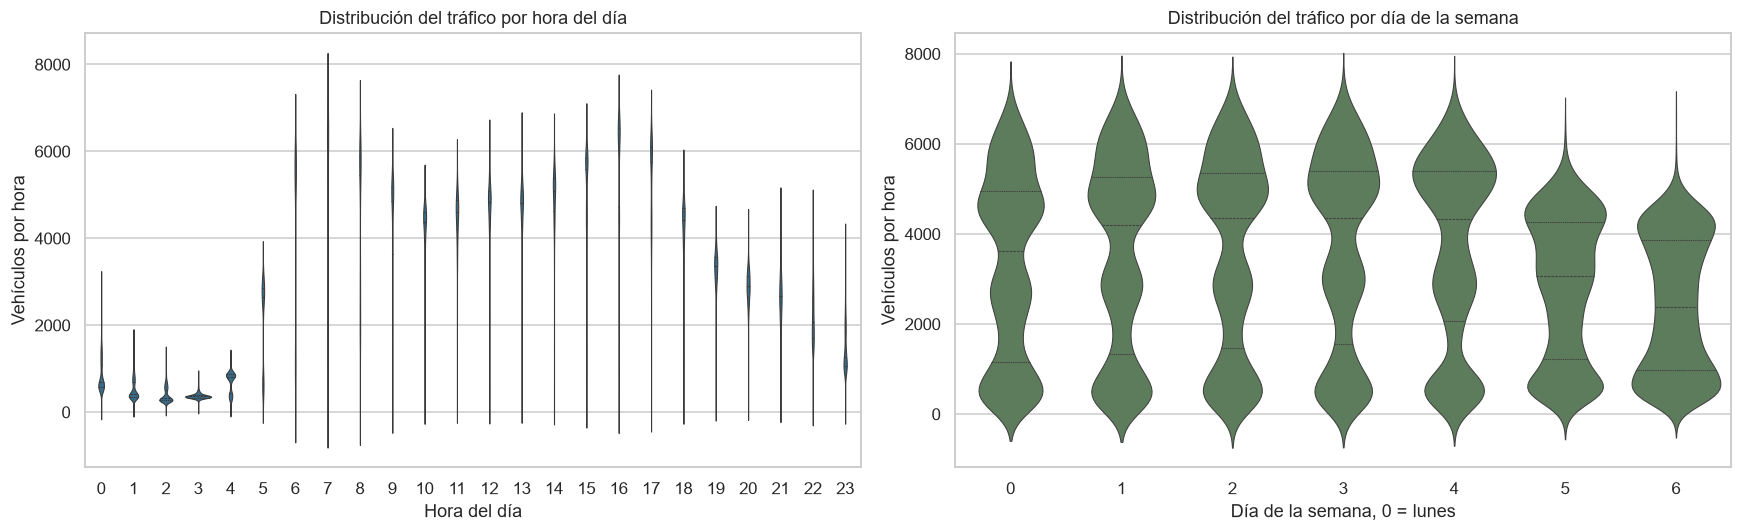

In [20]:
# 5. Distribución del tráfico por hora y por día de la semana
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
sns.violinplot(data=df, x='hour', y=OBJETIVO, ax=ax[0], color=AZUL,
               inner='quartile', linewidth=0.7)
ax[0].set_title('Distribución del tráfico por hora del día')
ax[0].set_xlabel('Hora del día')
ax[0].set_ylabel('Vehículos por hora')

sns.violinplot(data=df, x='weekday', y=OBJETIVO, ax=ax[1], color=VERDE,
               inner='quartile', linewidth=0.7)
ax[1].set_title('Distribución del tráfico por día de la semana')
ax[1].set_xlabel('Día de la semana, 0 = lunes')
ax[1].set_ylabel('Vehículos por hora')

plt.tight_layout()
plt.savefig('figures/fig07_violin_hora_dia.png', dpi=150, bbox_inches='tight')
plt.show()

**3.3 Partición train / test**

La partición se realiza **antes de ajustar cualquier transformador**, con
`random_state=42` y una proporción de 80/20. Todo lo hecho hasta este punto fue limpieza
estructural que no utiliza estadísticos de los datos, como deduplicar, pasar texto a
minúsculas, extraer la hora de una fecha o marcar valores físicamente imposibles. En
cambio, todo lo que sí aprende de los datos, como imputar con la mediana, estandarizar,
codificar categorías o ajustar el PCA, ocurre después de la partición y se ajusta
únicamente con `X_train`.

La ficha indica usar `stratify=y` en caso de clasificación. Este es un problema de
regresión y la variable objetivo es continua con 6.783 valores distintos, por lo que la
estratificación no corresponde y se omite de forma deliberada.

In [21]:
from sklearn.model_selection import train_test_split, GridSearchCV

# 1. Separar los predictores de la variable objetivo
X = df[PREDICTORAS].copy()
y = df[OBJETIVO].copy()

# 2. Dividir en train (80%) y test (20%) ANTES de ajustar cualquier transformador
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED)

print(f"X_train: {X_train.shape}")
print(f"X_test : {X_test.shape}")
print(f"Proporción de test: {len(X_test) / len(X):.1%}")
print(f"\nMedia de y_train: {y_train.mean():.2f} vehículos/hora")
print(f"Media de y_test : {y_test.mean():.2f} vehículos/hora")

X_train: (32460, 11)
X_test : (8115, 11)
Proporción de test: 20.0%

Media de y_train: 3287.43 vehículos/hora
Media de y_test : 3303.52 vehículos/hora


**3.4 Pipeline de preprocesamiento**

Todo el preprocesamiento se encapsula en un `ColumnTransformer` con tres bloques, de
modo que la imputación, la codificación y el escalado se ajusten solo con los datos de
entrenamiento:

* **Continuas:** `SimpleImputer(strategy='median')`, robusta frente a los outliers del
  EDA y responsable de imputar los 11 valores imposibles marcados antes, seguida de
  `StandardScaler`, indispensable porque la penalización L2 depende de la escala de los
  coeficientes y porque PCA y K-Means trabajan sobre distancias.
* **Ordinales:** imputación por moda, `OrdinalEncoder` y `StandardScaler`.
* **Nominales:** imputación por moda y `OneHotEncoder(handle_unknown='ignore')`, opción
  que evita que el pipeline falle si en test aparece una categoría de clima ausente en
  train.

La matriz final tiene **56 variables**, a partir de las 11 predictoras originales.

In [22]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

# Función que arma el ColumnTransformer con los tres bloques de preprocesamiento
def crear_preprocesador(continuas=CONTINUAS, ordinales=ORDINALES, nominales=NOMINALES):
    return ColumnTransformer([
        # a) Continuas: imputación por mediana, robusta a los outliers, y estandarización
        ('continuas', Pipeline([('imp', SimpleImputer(strategy='median')),
                                ('sc', StandardScaler())]), continuas),
        # b) Ordinales: imputación por moda, codificación ordinal y estandarización
        ('ordinales', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                                ('oe', OrdinalEncoder(handle_unknown='use_encoded_value',
                                                      unknown_value=-1)),
                                ('sc', StandardScaler())]), ordinales),
        # c) Nominales: imputación por moda y One-Hot Encoding
        ('nominales', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                                ('ohe', OneHotEncoder(handle_unknown='ignore',
                                                      sparse_output=False))]), nominales)])

# 1. Ajustar SOLO con train y transformar test, nunca al revés
preprocesador = crear_preprocesador()
X_train_prep = preprocesador.fit_transform(X_train)
X_test_prep = preprocesador.transform(X_test)
feat_names = preprocesador.get_feature_names_out()

print(f"X_train_prep: {X_train_prep.shape}")
print(f"X_test_prep : {X_test_prep.shape}")
print(f"Variables tras el preprocesamiento: {len(feat_names)}")

# 2. Verificar que la mediana de imputación se aprendió solo del conjunto de entrenamiento
mediana_temp = preprocesador.named_transformers_['continuas'].named_steps['imp'].statistics_[0]
print(f"\nMediana de temp aprendida solo de train: {mediana_temp:.4f} °C")

X_train_prep: (32460, 56)
X_test_prep : (8115, 56)
Variables tras el preprocesamiento: 56

Mediana de temp aprendida solo de train: 9.6800 °C


### 4. Análisis no supervisado: PCA y K-Means

**4.1 PCA sobre el conjunto de entrenamiento preprocesado**

Se necesitan **7 componentes para explicar el 80% de la varianza** y 9 para alcanzar el
90%, partiendo de 56 variables. La primera componente explica solo un 16,4%, lo que
indica que no existe una dirección dominante única.

La razón está en la estructura de la matriz. Las 7 variables continuas y ordinales
fueron estandarizadas y por lo tanto aportan varianza 1 cada una, mientras que las 49
columnas generadas por el One-Hot Encoding no se estandarizan y su varianza es p(1-p),
un valor pequeño para categorías poco frecuentes. En consecuencia, las primeras
componentes recogen esencialmente las variables densas y las dummies dispersas aportan
poco.

In [23]:
from sklearn.decomposition import PCA

# 1. Ajustar el PCA completo para conocer el perfil de varianza explicada
pca_completo = PCA(random_state=SEED).fit(X_train_prep)
var_exp = pca_completo.explained_variance_ratio_
var_acum = np.cumsum(var_exp)

n_80 = int(np.argmax(var_acum >= 0.80) + 1)
n_90 = int(np.argmax(var_acum >= 0.90) + 1)

tabla_pca = pd.DataFrame({
    'componente': [f'PC{i+1}' for i in range(len(var_exp))],
    'varianza_explicada_pct': (var_exp * 100).round(3),
    'varianza_acumulada_pct': (var_acum * 100).round(3)})

print(f"Componentes totales: {len(var_exp)}")
print(f"Componentes para explicar el 80% de la varianza: {n_80}")
print(f"Componentes para explicar el 90% de la varianza: {n_90}")
tabla_pca.head(15)

Componentes totales: 56
Componentes para explicar el 80% de la varianza: 7
Componentes para explicar el 90% de la varianza: 9


,componente,varianza_explicada_pct,varianza_acumulada_pct
0,PC1,16.263,16.263
1,PC2,14.295,30.559
2,PC3,14.019,44.577
3,PC4,11.317,55.894
4,PC5,11.113,67.007
5,PC6,10.737,77.744
6,PC7,7.909,85.653
7,PC8,3.176,88.829
8,PC9,2.056,90.885
9,PC10,1.599,92.484


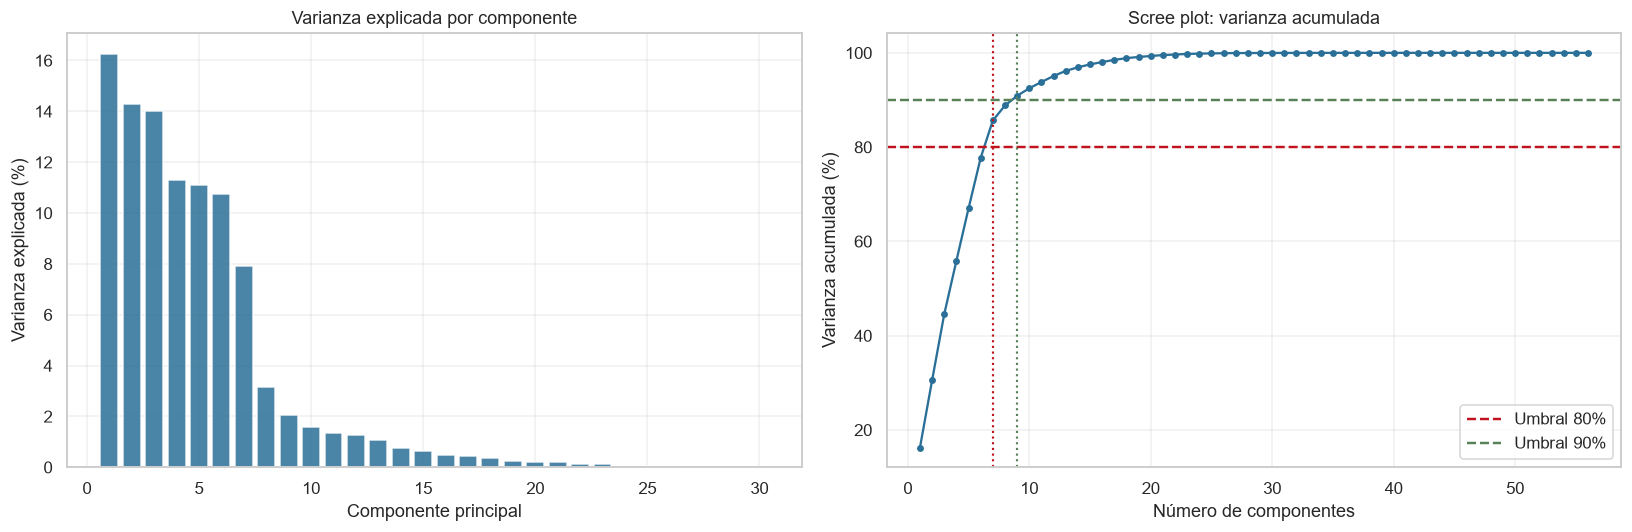

In [24]:
# 2. Scree plot con las líneas de referencia en 80% y 90%
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
k_mostrar = min(30, len(var_exp))

ax[0].bar(range(1, k_mostrar + 1), var_exp[:k_mostrar] * 100, color=AZUL, alpha=0.85)
ax[0].set_title('Varianza explicada por componente')
ax[0].set_xlabel('Componente principal')
ax[0].set_ylabel('Varianza explicada (%)')
ax[0].grid(alpha=0.3)

ax[1].plot(range(1, len(var_acum) + 1), var_acum * 100, marker='o', ms=3.5, color=AZUL)
ax[1].axhline(80, ls='--', color=ROJO, lw=1.6, label='Umbral 80%')
ax[1].axhline(90, ls='--', color=VERDE, lw=1.6, label='Umbral 90%')
ax[1].axvline(n_80, ls=':', color=ROJO, lw=1.4)
ax[1].axvline(n_90, ls=':', color=VERDE, lw=1.4)
ax[1].set_title('Scree plot: varianza acumulada')
ax[1].set_xlabel('Número de componentes')
ax[1].set_ylabel('Varianza acumulada (%)')
ax[1].legend()
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figures/fig08_scree_plot.png', dpi=150, bbox_inches='tight')
plt.show()

**4.2 Selección del número de componentes y loadings**

Se seleccionan **7 componentes**, que explican el 85,65% de la varianza y quedan dentro
del rango de 80% a 90% exigido. La reducción va de 56 a 7 dimensiones, es decir un 87,5%
menos, conservando la mayor parte de la información.

In [25]:
# 1. Ajustar el PCA definitivo con el número de componentes seleccionado
N_COMPONENTES = n_80
pca = PCA(n_components=N_COMPONENTES, random_state=SEED)
X_train_pca = pca.fit_transform(X_train_prep)
X_test_pca = pca.transform(X_test_prep)

print(f"Componentes seleccionados: {N_COMPONENTES}")
print(f"Varianza explicada acumulada: {pca.explained_variance_ratio_.sum():.4%}")
print(f"Reducción: de {X_train_prep.shape[1]} a {N_COMPONENTES} dimensiones, "
      f"un {1 - N_COMPONENTES / X_train_prep.shape[1]:.1%} menos")

Componentes seleccionados: 7
Varianza explicada acumulada: 85.6534%
Reducción: de 56 a 7 dimensiones, un 87.5% menos


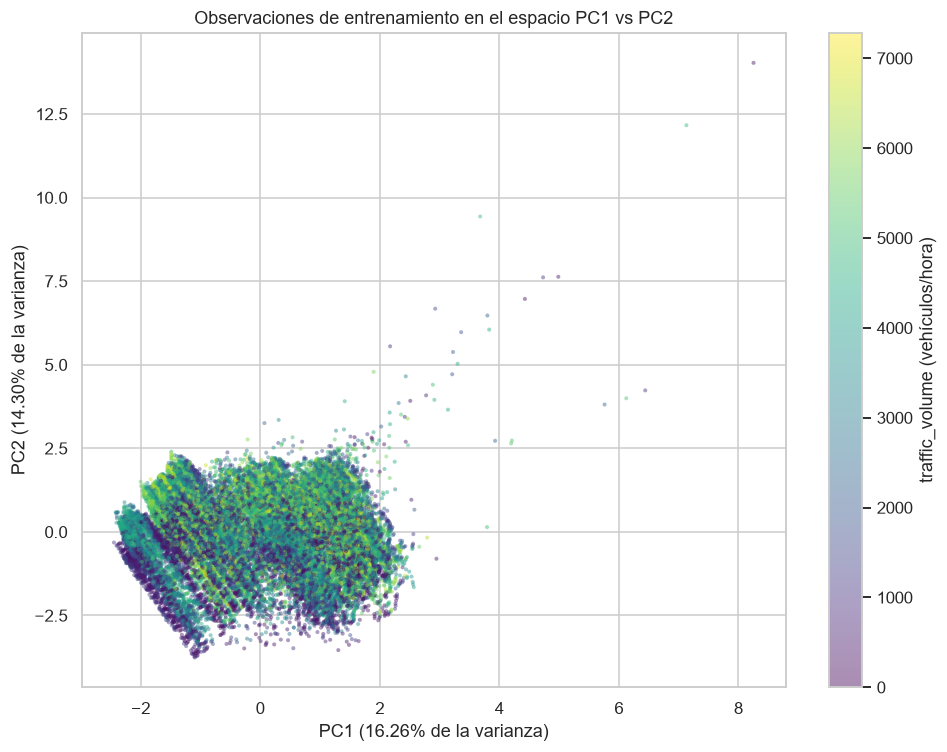

In [26]:
# 2. Proyectar las observaciones de entrenamiento sobre las dos primeras componentes
plt.figure(figsize=(9, 7))
grafico = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train,
                      cmap='viridis', s=7, alpha=0.45, edgecolors='none')
plt.colorbar(grafico, label='traffic_volume (vehículos/hora)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} de la varianza)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} de la varianza)')
plt.title('Observaciones de entrenamiento en el espacio PC1 vs PC2')
plt.tight_layout()
plt.savefig('figures/fig09_pca_pc1_pc2.png', dpi=150, bbox_inches='tight')
plt.show()

Top 5 contribuciones a PC1:
                                                PC1
continuas__clouds_all                        0.7452
nominales__weather_main_Clear               -0.3100
nominales__weather_description_sky is clear -0.3100
continuas__temp                             -0.2541
ordinales__weekday                          -0.2501

Top 5 contribuciones a PC2:
                       PC2
continuas__temp     0.5920
ordinales__month    0.4969
ordinales__weekday -0.4592
ordinales__hour     0.2786
continuas__rain_1h  0.1870


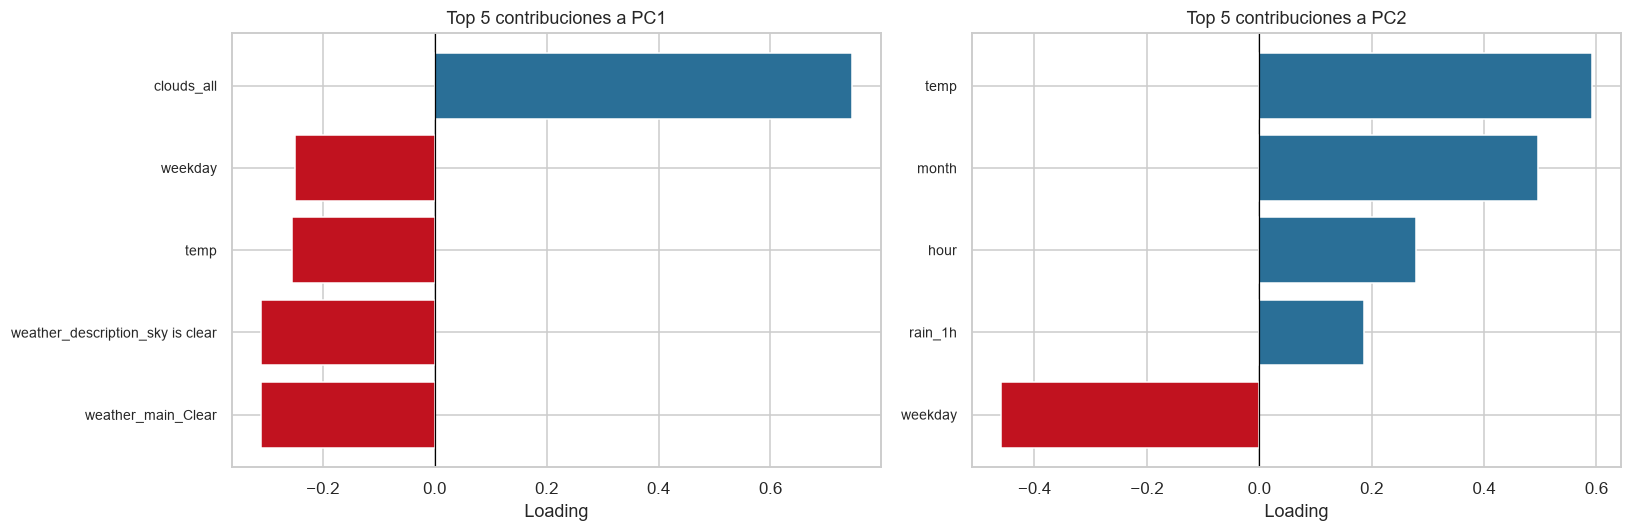

In [27]:
# 3. Identificar las cinco variables que más contribuyen a PC1 y a PC2
loadings = pd.DataFrame(pca.components_[:2].T, index=feat_names, columns=['PC1', 'PC2'])
top_pc1 = loadings['PC1'].abs().sort_values(ascending=False).head(5)
top_pc2 = loadings['PC2'].abs().sort_values(ascending=False).head(5)

print("Top 5 contribuciones a PC1:")
print(loadings.loc[top_pc1.index, ['PC1']].round(4))
print("\nTop 5 contribuciones a PC2:")
print(loadings.loc[top_pc2.index, ['PC2']].round(4))

# 4. Graficar ambos conjuntos de loadings
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
for i, (comp, top) in enumerate([('PC1', top_pc1), ('PC2', top_pc2)]):
    valores_top = loadings.loc[top.index, comp].sort_values()
    colores = [ROJO if v < 0 else AZUL for v in valores_top]
    ax[i].barh(range(len(valores_top)), valores_top.values, color=colores)
    ax[i].set_yticks(range(len(valores_top)))
    ax[i].set_yticklabels([t.split('__')[-1] for t in valores_top.index], fontsize=9)
    ax[i].axvline(0, color='black', lw=0.8)
    ax[i].set_title(f'Top 5 contribuciones a {comp}')
    ax[i].set_xlabel('Loading')
plt.tight_layout()
plt.savefig('figures/fig10_loadings.png', dpi=150, bbox_inches='tight')
plt.show()

**4.3 K-Means: primer intento y diagnóstico de un resultado degenerado**

Se aplica K-Means para K entre 2 y 10 sobre el espacio PCA. El Silhouette Score se
calcula sobre una submuestra aleatoria de 5.000 puntos, ya que es un cálculo de orden
cuadrático y con 32.460 observaciones resultaría inviable.

El resultado **no es utilizable tal como sale**. Con K = 3 los tamaños de los grupos son
19.125, 13.326 y **9 observaciones**. Un cluster de 9 puntos sobre 32.460 no es un
segmento, es un artefacto, y el problema se repite en casi todos los valores de K.

In [28]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. Recorrer K de 2 a 10 registrando inercia, silhouette y tamaño de los grupos
rango_k = range(2, 11)
inercias, silhouettes, minimos = [], [], []

rng = np.random.RandomState(SEED)
idx_sil = rng.choice(len(X_train_pca), size=min(5000, len(X_train_pca)), replace=False)

for k in rango_k:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    etiquetas = km.fit_predict(X_train_pca)
    inercias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_train_pca[idx_sil], etiquetas[idx_sil]))
    minimos.append(int(np.bincount(etiquetas).min()))

tabla_k = pd.DataFrame({'K': list(rango_k),
                        'inercia': np.round(inercias, 1),
                        'silhouette': np.round(silhouettes, 4),
                        'cluster_mas_pequeno': minimos})
print(tabla_k.to_string(index=False))

 K  inercia  silhouette  cluster_mas_pequeno
 2 210971.5      0.2175                13348
 3 184844.0      0.2186                    9
 4 163855.2      0.2060                    8
 5 147209.1      0.2060                    9
 6 136576.0      0.2147                    8
 7 122817.5      0.2117                    8
 8 107931.8      0.2293                    9
 9  99599.3      0.2354                    9
10  92204.6      0.2366                    9


In [29]:
# 2. Inspeccionar qué son las observaciones del cluster degenerado con K = 3
km3 = KMeans(n_clusters=3, random_state=SEED, n_init=10).fit(X_train_pca)
cluster_pequeno = np.bincount(km3.labels_).argmin()
mascara_peq = km3.labels_ == cluster_pequeno

print(f"Observaciones en el cluster más pequeño: {int(mascara_peq.sum())}")
print(X_train[mascara_peq][['weather_main', 'weather_description', 'temp',
                            'rain_1h', 'snow_1h', 'clouds_all', 'hour']].to_string())

Observaciones en el cluster más pequeño: 9
      weather_main weather_description  temp  rain_1h  snow_1h  clouds_all  hour
17348         Snow          light snow  0.71     0.00     0.32          90    16
17439         Snow                snow -6.01     0.00     0.44          90    22
17607         Snow          light snow  0.13     0.00     0.17          90     1
17440         Snow                snow -6.09     0.00     0.51          90    23
17394         Snow          light snow -1.98     0.00     0.21          90     9
17346         Rain       moderate rain  1.18     0.98     0.51          90    12
17615         Snow          light snow  0.65     0.00     0.25          90    13
17438         Snow                snow -5.90     0.00     0.25          90    21
17347         Snow          light snow  0.59     0.00     0.32          90    14


In [30]:
# 3. Cuantificar la varianza de snow_1h, que es la causa del problema
ceros = int((X_train['snow_1h'] == 0).sum())
z_max = ((X_train['snow_1h'] - X_train['snow_1h'].mean()) / X_train['snow_1h'].std()).max()

print(f"snow_1h igual a cero: {ceros} de {len(X_train)} ({ceros / len(X_train):.4%})")
print(f"snow_1h distinto de cero: {len(X_train) - ceros} registros")
print(f"Desviación estándar de snow_1h: {X_train['snow_1h'].std():.6f}")
print(f"Z-score máximo tras estandarizar: {z_max:.2f}")

snow_1h igual a cero: 32435 de 32460 (99.9230%)
snow_1h distinto de cero: 25 registros
Desviación estándar de snow_1h: 0.006146
Z-score máximo tras estandarizar: 82.96


**Diagnóstico.** Las 9 observaciones aisladas son todas eventos de nieve. La causa es
`snow_1h`, que vale exactamente cero en el **99,92%** de los registros de entrenamiento y
tiene una desviación estándar de 0,0062. Al estandarizarla, los 25 registros con nieve
se transforman en puntos situados hasta **83 desviaciones estándar** del centro. K-Means
minimiza la suma de distancias al cuadrado, de modo que aislar esos puntos en su propio
grupo reduce muchísimo la inercia y el algoritmo lo hace de forma sistemática.

Es un caso de manual de variable con varianza cercana a cero. La corrección consiste en
excluir `snow_1h` del espacio de segmentación, ya que no aporta información para
distinguir grupos de horas. La variable se **mantiene en el pipeline supervisado**, donde
los modelos basados en árboles la manejan sin problema por trabajar con cortes y no con
distancias.

In [31]:
# 1. Reconstruir el espacio de segmentación excluyendo snow_1h
CONTINUAS_CLUSTER = ['temp', 'rain_1h', 'clouds_all']
prep_cluster = crear_preprocesador(continuas=CONTINUAS_CLUSTER)
X_cluster_prep = prep_cluster.fit_transform(X_train)

# 2. Ajustar un PCA nuevo sobre ese espacio, con el mismo criterio del 80%
pca_cl_completo = PCA(random_state=SEED).fit(X_cluster_prep)
var_acum_cl = np.cumsum(pca_cl_completo.explained_variance_ratio_)
n_comp_cl = int(np.argmax(var_acum_cl >= 0.80) + 1)

pca_cluster = PCA(n_components=n_comp_cl, random_state=SEED)
X_cluster_pca = pca_cluster.fit_transform(X_cluster_prep)

print(f"Variables del espacio de segmentación: {X_cluster_prep.shape[1]}")
print(f"Componentes para el 80% de la varianza: {n_comp_cl}")
print(f"Varianza explicada acumulada: {pca_cluster.explained_variance_ratio_.sum():.4%}")

Variables del espacio de segmentación: 55
Componentes para el 80% de la varianza: 6
Varianza explicada acumulada: 83.8586%


In [32]:
# 3. Repetir la búsqueda de K sobre el espacio corregido
inercias_c, silhouettes_c, minimos_c = [], [], []
for k in rango_k:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    etiquetas = km.fit_predict(X_cluster_pca)
    inercias_c.append(km.inertia_)
    silhouettes_c.append(silhouette_score(X_cluster_pca[idx_sil], etiquetas[idx_sil]))
    minimos_c.append(int(np.bincount(etiquetas).min()))

tabla_kc = pd.DataFrame({'K': list(rango_k),
                         'inercia': np.round(inercias_c, 1),
                         'silhouette': np.round(silhouettes_c, 4),
                         'cluster_mas_pequeno': minimos_c})
print("Búsqueda de K sobre el espacio corregido, sin snow_1h:")
print(tabla_kc.to_string(index=False))

Búsqueda de K sobre el espacio corregido, sin snow_1h:
 K  inercia  silhouette  cluster_mas_pequeno
 2 178498.9      0.2194                13300
 3 157275.0      0.2120                 8439
 4 140848.0      0.2064                 7402
 5 123764.1      0.2128                   41
 6 112386.8      0.2169                   41
 7 101560.9      0.2303                   41
 8  93227.9      0.2364                   41
 9  85881.9      0.2380                   16
10  79210.8      0.2422                   12


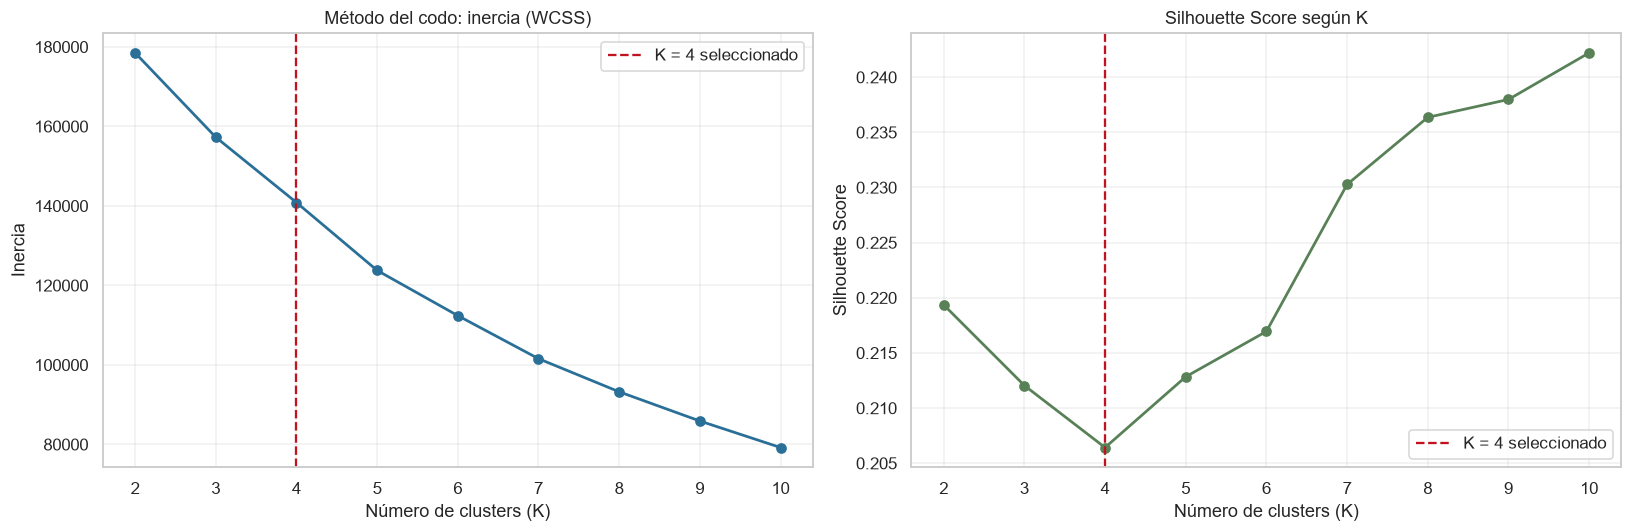

Rango de silhouette observado: 0.2064 a 0.2422


In [33]:
# 4. Graficar el método del codo y el Silhouette Score
K_OPTIMO = 4

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].plot(list(rango_k), inercias_c, marker='o', color=AZUL, lw=1.8)
ax[0].axvline(K_OPTIMO, ls='--', color=ROJO, lw=1.5, label=f'K = {K_OPTIMO} seleccionado')
ax[0].set_title('Método del codo: inercia (WCSS)')
ax[0].set_xlabel('Número de clusters (K)')
ax[0].set_ylabel('Inercia')
ax[0].legend()
ax[0].grid(alpha=0.3)

ax[1].plot(list(rango_k), silhouettes_c, marker='o', color=VERDE, lw=1.8)
ax[1].axvline(K_OPTIMO, ls='--', color=ROJO, lw=1.5, label=f'K = {K_OPTIMO} seleccionado')
ax[1].set_title('Silhouette Score según K')
ax[1].set_xlabel('Número de clusters (K)')
ax[1].set_ylabel('Silhouette Score')
ax[1].legend()
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figures/fig11_codo_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Rango de silhouette observado: {min(silhouettes_c):.4f} a {max(silhouettes_c):.4f}")

**4.4 Selección del K óptimo**

Se selecciona **K = 4**, y conviene explicar por qué no se escoge el K con mayor
Silhouette absoluto.

El Silhouette crece de manera casi monótona hasta K = 10, pero todo el rango se mueve
entre 0,206 y 0,242. Son valores bajos, propios de una estructura de grupos débil y con
fronteras difusas, y la diferencia entre el mejor y el peor K es de apenas 0,036, muy por
debajo de lo que justificaría preferir una solución de diez grupos. Perseguir ese máximo
sería sobreinterpretar ruido.

Existe además un criterio más exigente: a partir de K = 5 vuelven a aparecer clusters
degenerados de 41 observaciones o menos, provocados ahora por las categorías de clima poco
frecuentes codificadas en one-hot, como `squall`, con un solo registro en train. **K = 4
es el mayor valor de K que produce cuatro grupos equilibrados**, con tamaños de 7.402,
7.559, 7.595 y 9.904 observaciones.

Por último, K = 4 es el único que separa algo con significado operativo, ya que aísla el
fin de semana del resto, como se verifica en el perfil siguiente.

In [34]:
# 1. Ajustar K-Means con el K seleccionado y asignar los clusters
kmeans = KMeans(n_clusters=K_OPTIMO, random_state=SEED, n_init=10)
clusters_train = kmeans.fit_predict(X_cluster_pca)

print("Distribución de observaciones por cluster:")
print(pd.Series(clusters_train).value_counts().sort_index())

Distribución de observaciones por cluster:
0    7559
1    7595
2    7402
3    9904
Name: count, dtype: int64


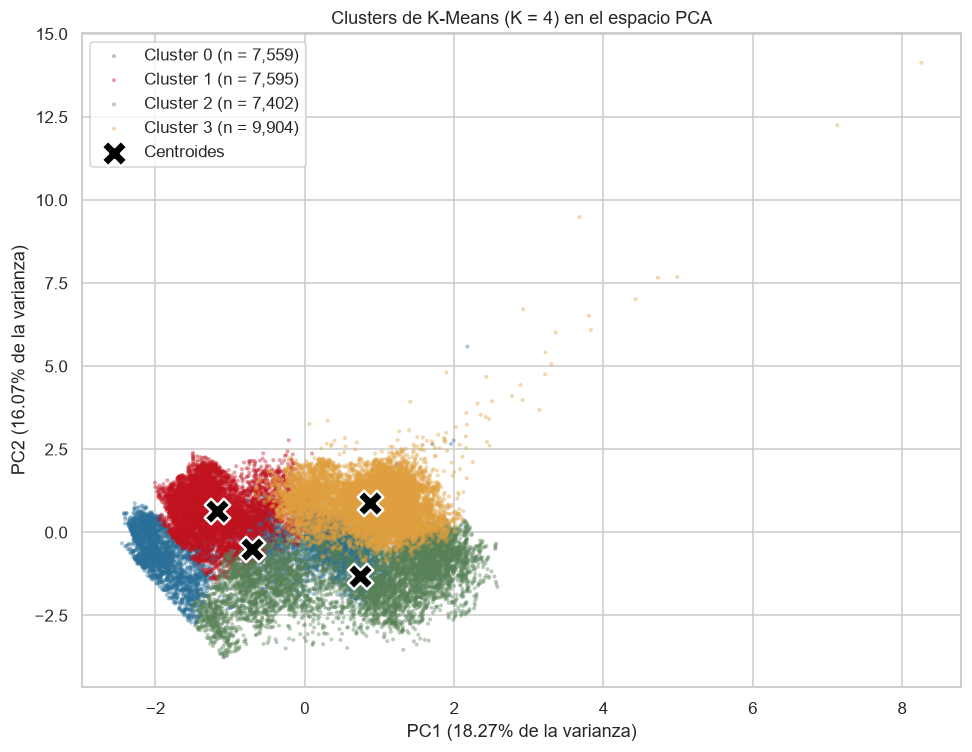

In [35]:
# 2. Visualizar los clusters en el espacio de las dos primeras componentes
plt.figure(figsize=(9, 7))
paleta_clusters = [AZUL, ROJO, VERDE, '#e09f3e']
for c in range(K_OPTIMO):
    m = clusters_train == c
    plt.scatter(X_cluster_pca[m, 0], X_cluster_pca[m, 1], s=7, alpha=0.4,
                color=paleta_clusters[c], edgecolors='none',
                label=f'Cluster {c} (n = {m.sum():,})')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            marker='X', s=280, c='black', edgecolors='white', linewidths=1.6,
            label='Centroides', zorder=5)
plt.xlabel(f'PC1 ({pca_cluster.explained_variance_ratio_[0]:.2%} de la varianza)')
plt.ylabel(f'PC2 ({pca_cluster.explained_variance_ratio_[1]:.2%} de la varianza)')
plt.title(f'Clusters de K-Means (K = {K_OPTIMO}) en el espacio PCA')
plt.legend()
plt.tight_layout()
plt.savefig('figures/fig12_clusters_pca.png', dpi=150, bbox_inches='tight')
plt.show()

In [36]:
# 3. Calcular la media de cada variable por cluster para construir el perfil
perfil_base = X_train.copy()
perfil_base['cluster'] = clusters_train
perfil_base['traffic_volume'] = y_train.values

vars_perfil = ['hour', 'weekday', 'month', 'temp', 'rain_1h', 'clouds_all',
               'is_weekend', 'is_holiday', 'traffic_volume']
perfil = perfil_base.groupby('cluster')[vars_perfil].mean().round(2)
perfil['n_observaciones'] = perfil_base.groupby('cluster').size()
print("Perfil de clusters, media de cada variable por grupo:")
print(perfil.to_string())

print("\nCondición meteorológica dominante en cada cluster:")
print(perfil_base.groupby('cluster')['weather_main'].agg(lambda s: s.value_counts().index[0]))

Perfil de clusters, media de cada variable por grupo:
          hour  weekday  month   temp  rain_1h  clouds_all  is_weekend  is_holiday  traffic_volume  n_observaciones
cluster                                                                                                            
0        11.66     5.50   7.58  12.13     0.07       39.54        0.99        0.00         2679.28             7559
1        10.86     2.01   7.48  14.22     0.01        2.59        0.00        0.04         3331.32             7595
2        10.88     2.93   2.10  -6.51     0.01       53.08        0.24        0.03         3194.78             7402
3        12.37     1.91   8.18  11.61     0.17       72.74        0.00        0.05         3787.18             9904

Condición meteorológica dominante en cada cluster:
cluster
0     Clear
1     Clear
2    Clouds
3    Clouds
Name: weather_main, dtype: str


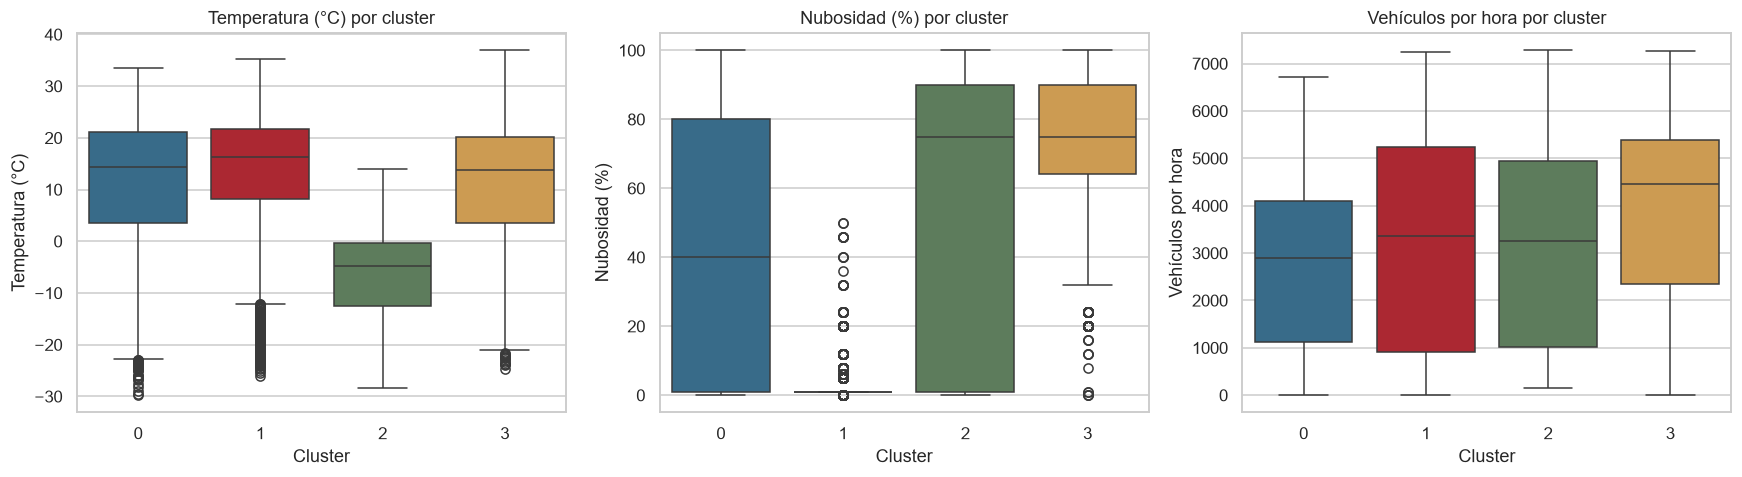

Hora media por cluster (para contrastar con la interpretación):
cluster
0    11.66
1    10.86
2    10.88
3    12.37
Name: hour, dtype: float64


In [37]:
# 4. Comparar los clusters en las variables que efectivamente los separan
fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
for i, (col, etiqueta) in enumerate([('temp', 'Temperatura (°C)'),
                                     ('clouds_all', 'Nubosidad (%)'),
                                     ('traffic_volume', 'Vehículos por hora')]):
    sns.boxplot(data=perfil_base, x='cluster', y=col, ax=ax[i],
                hue='cluster', palette=paleta_clusters, legend=False)
    ax[i].set_title(f'{etiqueta} por cluster')
    ax[i].set_xlabel('Cluster')
    ax[i].set_ylabel(etiqueta)
plt.tight_layout()
plt.savefig('figures/fig13_perfil_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

# 5. Contrastar la hora media, que es la variable que NO separa a los grupos
print("Hora media por cluster (para contrastar con la interpretación):")
print(perfil_base.groupby('cluster')['hour'].mean().round(2))

**4.5 Interpretación de los clusters**

Los cuatro grupos se interpretan de la siguiente manera:

* **Cluster 2 (7.402 obs):** mes 2,1 y temperatura media de -6,5 °C. Corresponde al
  **invierno de Minnesota**, con 53% de nubosidad media y 3.195 vehículos por hora.
* **Cluster 1 (7.595 obs):** temperatura de 14,2 °C y apenas 2,6% de nubosidad. Es la
  **temporada cálida con cielo despejado** en días laborales, con 3.331 vehículos por hora.
* **Cluster 3 (9.904 obs):** temperatura de 11,6 °C y 72,7% de nubosidad, también en días
  laborales. Es la **temporada cálida con cielo cubierto** y registra el tráfico más alto,
  con 3.787 vehículos por hora.
* **Cluster 0 (7.559 obs):** `is_weekend` igual a 0,99, es decir el grupo del **fin de
  semana**, con el tráfico más bajo de los cuatro, 2.679 vehículos por hora.

Aquí aparece el hallazgo más importante de esta sección, y conviene enunciarlo con
franqueza. **Los clusters se organizan por estación del año, nubosidad y tipo de día, no
por régimen horario de tráfico.** La hora media es prácticamente idéntica en los cuatro
grupos, entre 10,9 y 12,4, de modo que la segmentación no recuperó los dos regímenes que
el análisis de la variable objetivo había anticipado en el punto 2.

La explicación es instructiva. K-Means y PCA son métodos no supervisados y encuentran la
estructura que domina la **varianza** del espacio de predictores, que en este caso es
meteorológica y estacional, porque el clima aporta muchas variables correlacionadas entre
sí. La hora es una sola dimensión entre 55 y queda diluida, pese a que en el punto 5 se
demostrará que concentra el 85% de la importancia predictiva.

La lección es que **la varianza no equivale a la relevancia predictiva**. Un
Silhouette de 0,21 confirma además que estos datos no presentan grupos naturalmente
separados, ya que la variable que realmente ordena el fenómeno es continua y cíclica, y
K-Means impone cortes sobre un continuo en lugar de descubrir agrupaciones discretas. Los
clusters sirven como descripción del clima de Minneapolis, no como evidencia de que
existan cuatro tipos de horas esencialmente distintos.

### 5. Modelado supervisado

Se comparan tres modelos: un baseline que predice siempre la media, un modelo penalizado
con L2 (Ridge) y un modelo basado en árboles (Random Forest). El baseline no lo exige la
ficha, pero sin un piso de comparación ninguna métrica tiene interpretación. Los tres
comparten el mismo preprocesamiento y usan `random_state=42`.

La métrica principal es el **RMSE**, expresado en vehículos por hora y por lo tanto
directamente interpretable en el dominio del problema.

In [38]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Función que calcula el MAPE excluyendo los valores reales muy cercanos a cero
def calcular_mape(y_real, y_pred):
    y_real = np.asarray(y_real, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mascara = np.abs(y_real) > 1e-9
    return float(np.mean(np.abs((y_real[mascara] - y_pred[mascara]) / y_real[mascara])) * 100)

# Función que reúne las cuatro métricas de regresión exigidas por la ficha
def calcular_metricas(y_real, y_pred):
    return {'RMSE': float(np.sqrt(mean_squared_error(y_real, y_pred))),
            'MAE': float(mean_absolute_error(y_real, y_pred)),
            'R2': float(r2_score(y_real, y_pred)),
            'MAPE': calcular_mape(y_real, y_pred)}

**5.1 Baseline: predicción por la media**

In [39]:
# 1. Entrenar el baseline, que predice siempre la media del conjunto de entrenamiento
t0 = time.time()
baseline = DummyRegressor(strategy='mean').fit(X_train_prep, y_train)
t_baseline = time.time() - t0

print(f"Baseline entrenado en {t_baseline:.4f} s")
print(f"Predicción constante: {baseline.constant_[0][0]:.2f} vehículos/hora")

Baseline entrenado en 0.0000 s
Predicción constante: 3287.43 vehículos/hora


**5.2 Ridge (L2) con búsqueda de alpha**

Se optimiza `alpha` sobre la grilla indicada en la ficha, con validación cruzada de 5
folds. El óptimo es **alpha = 10**, con un RMSE de validación cruzada de 1.773,15
vehículos por hora.

La curva es prácticamente plana, ya que entre el mejor y el peor valor de alpha hay
menos de 0,5 vehículos por hora de diferencia en RMSE. Con 32.460 observaciones y 56
variables no hay varianza que reducir, de modo que la penalización L2 no aporta
discriminación adicional. El problema de este modelo no es la regularización, como se
analiza en el punto 6.

In [40]:
# 1. Optimizar alpha con GridSearchCV de 5 folds sobre la grilla de la ficha
alphas = [0.001, 0.01, 0.1, 1, 10, 100]
t0 = time.time()
gs_ridge = GridSearchCV(Ridge(random_state=SEED), {'alpha': alphas}, cv=5,
                        scoring='neg_root_mean_squared_error', n_jobs=-1)
gs_ridge.fit(X_train_prep, y_train)
t_grid_ridge = time.time() - t0

print(f"Mejores hiperparámetros: {gs_ridge.best_params_}")
print(f"Mejor RMSE de validación cruzada: {-gs_ridge.best_score_:.4f}")
print(f"Tiempo de búsqueda: {t_grid_ridge:.2f} s")

# 2. Revisar el comportamiento de la métrica en toda la grilla
print("\nResultados por valor de alpha:")
print(pd.DataFrame({'alpha': alphas,
                    'RMSE_cv': np.round(-gs_ridge.cv_results_['mean_test_score'], 4),
                    'desv_std': np.round(gs_ridge.cv_results_['std_test_score'], 4)}).to_string(index=False))

Mejores hiperparámetros: {'alpha': 10}
Mejor RMSE de validación cruzada: 1773.1535
Tiempo de búsqueda: 2.74 s

Resultados por valor de alpha:
  alpha   RMSE_cv  desv_std
  0.001 1773.3641    2.9436
  0.010 1773.3618    2.9444
  0.100 1773.3407    2.9511
  1.000 1773.2329    2.9892
 10.000 1773.1535    3.0716
100.000 1773.6431    3.0775


**5.3 Random Forest con búsqueda de hiperparámetros**

Se optimizan `n_estimators`, `max_depth` y `min_samples_split` con validación cruzada de
5 folds, lo que implica 12 combinaciones y 60 ajustes. La mejor configuración es
**300 árboles, profundidad máxima 20 y mínimo 10 muestras para dividir**, con un RMSE de
validación cruzada de 395,23 vehículos por hora.

In [41]:
# 1. Optimizar los tres hiperparámetros con GridSearchCV de 5 folds
grid_rf = {'n_estimators': [100, 300],
           'max_depth': [None, 10, 20],
           'min_samples_split': [2, 10]}

t0 = time.time()
gs_rf = GridSearchCV(RandomForestRegressor(random_state=SEED, n_jobs=1), grid_rf, cv=5,
                     scoring='neg_root_mean_squared_error', n_jobs=-1)
gs_rf.fit(X_train_prep, y_train)
t_grid_rf = time.time() - t0

print(f"Combinaciones evaluadas: {len(gs_rf.cv_results_['params'])} x 5 folds")
print(f"Mejores hiperparámetros: {gs_rf.best_params_}")
print(f"Mejor RMSE de validación cruzada: {-gs_rf.best_score_:.4f}")
print(f"Tiempo de búsqueda: {t_grid_rf:.2f} s")

Combinaciones evaluadas: 12 x 5 folds
Mejores hiperparámetros: {'max_depth': 20, 'min_samples_split': 10, 'n_estimators': 300}
Mejor RMSE de validación cruzada: 395.2251
Tiempo de búsqueda: 114.38 s


In [42]:
# 2. Revisar las mejores combinaciones de la grilla
resultados_rf = pd.DataFrame(gs_rf.cv_results_)[
    ['param_n_estimators', 'param_max_depth', 'param_min_samples_split',
     'mean_test_score', 'std_test_score']].copy()
resultados_rf['RMSE_cv'] = (-resultados_rf['mean_test_score']).round(4)
resultados_rf = resultados_rf.drop(columns=['mean_test_score']).sort_values('RMSE_cv')
print(resultados_rf.head(12).to_string(index=False))

 param_n_estimators param_max_depth  param_min_samples_split  std_test_score  RMSE_cv
                300              20                       10       10.210371 395.2251
                300            None                       10       10.258625 395.6864
                100              20                       10       10.200228 395.7716
                100            None                       10       10.265014 396.2463
                300              20                        2       11.891826 402.2547
                100              20                        2       11.880992 403.0702
                300            None                        2       11.644498 404.2991
                100            None                        2       11.482395 405.1406
                300              10                        2        9.816588 408.0239
                300              10                       10        9.175400 408.0693
                100              10                   

**5.4 Tiempos de entrenamiento y predicción sobre test**

Esta es la primera y única vez que se utiliza `X_test_prep`, y solo para predecir. En
ningún momento se ajustó un modelo o un transformador con datos de test.

In [43]:
from sklearn.base import clone

# Función que reentrena un estimador con sus mejores hiperparámetros y mide el tiempo
def reentrenar_y_medir(estimador):
    modelo = clone(estimador)
    t0 = time.time()
    modelo.fit(X_train_prep, y_train)
    return modelo, time.time() - t0

# 1. Reentrenar los tres modelos midiendo el tiempo de forma comparable
baseline, t_fit_baseline = reentrenar_y_medir(baseline)
ridge, t_fit_ridge = reentrenar_y_medir(gs_ridge.best_estimator_)
rf, t_fit_rf = reentrenar_y_medir(gs_rf.best_estimator_)

modelos = {'Baseline (media)': (baseline, t_fit_baseline),
           'Ridge (L2)': (ridge, t_fit_ridge),
           'Random Forest': (rf, t_fit_rf)}

# 2. Generar las predicciones sobre test midiendo el tiempo de inferencia
predicciones, tiempos_inferencia = {}, {}
for nombre, (modelo, t_fit) in modelos.items():
    t0 = time.time()
    predicciones[nombre] = modelo.predict(X_test_prep)
    tiempos_inferencia[nombre] = time.time() - t0
    print(f"{nombre:18s} | entrenamiento {t_fit:7.4f} s | inferencia {tiempos_inferencia[nombre]:.4f} s")

Baseline (media)   | entrenamiento  0.0000 s | inferencia 0.0000 s
Ridge (L2)         | entrenamiento  0.0098 s | inferencia 0.0013 s


Random Forest      | entrenamiento 21.7909 s | inferencia 0.2658 s


**5.5 Métricas sobre el conjunto de test**

Una advertencia sobre el MAPE. Los valores que arroja son muy altos y **no deben leerse
como error porcentual real**. La variable objetivo alcanza mínimos de 2 vehículos por
hora durante la madrugada, de modo que equivocarse por 300 vehículos sobre un valor real
de 2 produce un error de 15.000%, y ese puñado de horas domina el promedio. El MAPE es
una métrica inadecuada para objetivos que toman valores cercanos a cero. Se reporta
porque la ficha lo exige, pero la métrica principal de este trabajo es el RMSE.

In [44]:
# 1. Calcular las cuatro métricas exigidas para cada modelo, con 4 decimales
for nombre, pred in predicciones.items():
    m = calcular_metricas(y_test, pred)
    print(f"--- {nombre} ---")
    for clave, valor in m.items():
        print(f"    {clave:5s}: {valor:.4f}")

--- Baseline (media) ---
    RMSE : 1979.3329
    MAE  : 1738.0349
    R2   : -0.0001
    MAPE : 218.0661
--- Ridge (L2) ---
    RMSE : 1766.1594
    MAE  : 1545.6485
    R2   : 0.2037
    MAPE : 164.7442
--- Random Forest ---
    RMSE : 385.7384
    MAE  : 237.5301
    R2   : 0.9620
    MAPE : 45.8347


**5.6 Tabla comparativa**

La tabla reúne los tres modelos como filas y todas las métricas más los tiempos como
columnas, ordenada por la métrica principal. Se incluyen también las métricas sobre train
y la brecha de R2, necesarias para diagnosticar sobreajuste en el punto 6.

In [45]:
# 1. Construir la tabla comparativa con métricas de test, de train y tiempos
filas_tabla = []
for nombre, (modelo, t_fit) in modelos.items():
    m_test = calcular_metricas(y_test, predicciones[nombre])
    m_train = calcular_metricas(y_train, modelo.predict(X_train_prep))
    filas_tabla.append({'Modelo': nombre,
                        'RMSE test': round(m_test['RMSE'], 4),
                        'MAE test': round(m_test['MAE'], 4),
                        'R2 test': round(m_test['R2'], 4),
                        'MAPE test': round(m_test['MAPE'], 4),
                        'RMSE train': round(m_train['RMSE'], 4),
                        'R2 train': round(m_train['R2'], 4),
                        'Brecha R2': round(m_train['R2'] - m_test['R2'], 4),
                        'Tiempo entrenamiento (s)': round(t_fit, 4),
                        'Tiempo inferencia (s)': round(tiempos_inferencia[nombre], 4)})

tabla_comparativa = pd.DataFrame(filas_tabla).sort_values('RMSE test').reset_index(drop=True)

# 2. Exportar la tabla al repositorio
tabla_comparativa.to_csv('resultados_modelos.csv', index=False)
print("Tabla exportada a resultados_modelos.csv")
tabla_comparativa

Tabla exportada a resultados_modelos.csv


,Modelo,RMSE test,MAE test,R2 test,MAPE test,RMSE train,R2 train,Brecha R2,Tiempo entrenamiento (s),Tiempo inferencia (s)
0,Random Forest,385.7384,237.5301,0.9620,45.8347,262.4678,0.9825,0.0205,21.7909,0.2658
1,Ridge (L2),1766.1594,1545.6485,0.2037,164.7442,1771.3994,0.2045,0.0008,0.0098,0.0013
2,Baseline (media),1979.3329,1738.0349,-0.0001,218.0661,1986.1033,0.0000,0.0001,0.0000,0.0000


**5.7 Valores reales frente a predichos y análisis de residuales**

Mejor modelo según RMSE de test: Random Forest


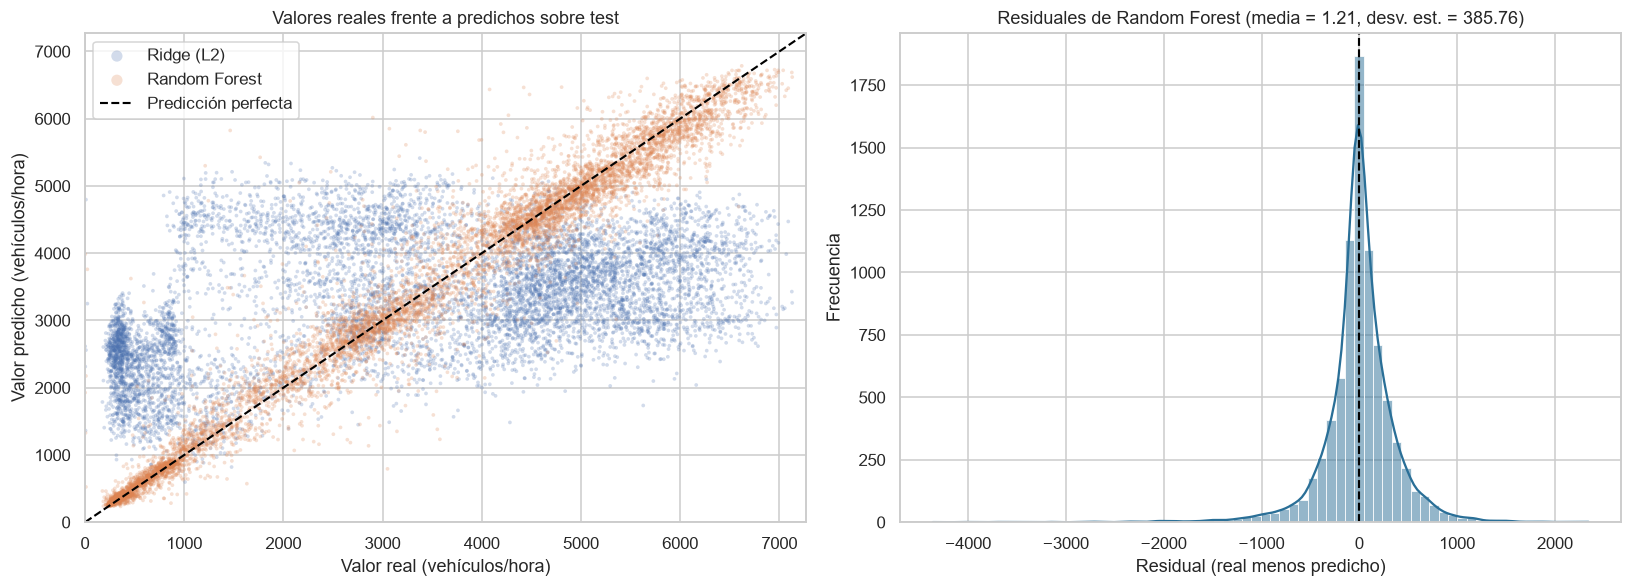

In [46]:
# 1. Identificar el mejor modelo según la métrica principal
mejor_nombre = tabla_comparativa.loc[0, 'Modelo']
mejor_modelo = modelos[mejor_nombre][0]
mejor_pred = predicciones[mejor_nombre]
residuales = y_test - mejor_pred
print(f"Mejor modelo según RMSE de test: {mejor_nombre}")

# 2. Graficar valores reales contra predichos y el histograma de residuales
fig, ax = plt.subplots(1, 2, figsize=(15, 5.5))
for nombre, pred in predicciones.items():
    if nombre == 'Baseline (media)':
        continue
    ax[0].scatter(y_test, pred, s=6, alpha=0.25, label=nombre, edgecolors='none')
limites = [0, y_test.max() * 1.02]
ax[0].plot(limites, limites, '--', color='black', lw=1.4, label='Predicción perfecta')
ax[0].set_xlim(limites)
ax[0].set_ylim(limites)
ax[0].set_xlabel('Valor real (vehículos/hora)')
ax[0].set_ylabel('Valor predicho (vehículos/hora)')
ax[0].set_title('Valores reales frente a predichos sobre test')
ax[0].legend(markerscale=3)

sns.histplot(residuales, bins=70, kde=True, color=AZUL, ax=ax[1])
ax[1].axvline(0, ls='--', color='black', lw=1.4)
ax[1].set_title(f'Residuales de {mejor_nombre} '
                f'(media = {residuales.mean():.2f}, desv. est. = {residuales.std():.2f})')
ax[1].set_xlabel('Residual (real menos predicho)')
ax[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.savefig('figures/fig14_real_vs_predicho_residuales.png', dpi=150, bbox_inches='tight')
plt.show()

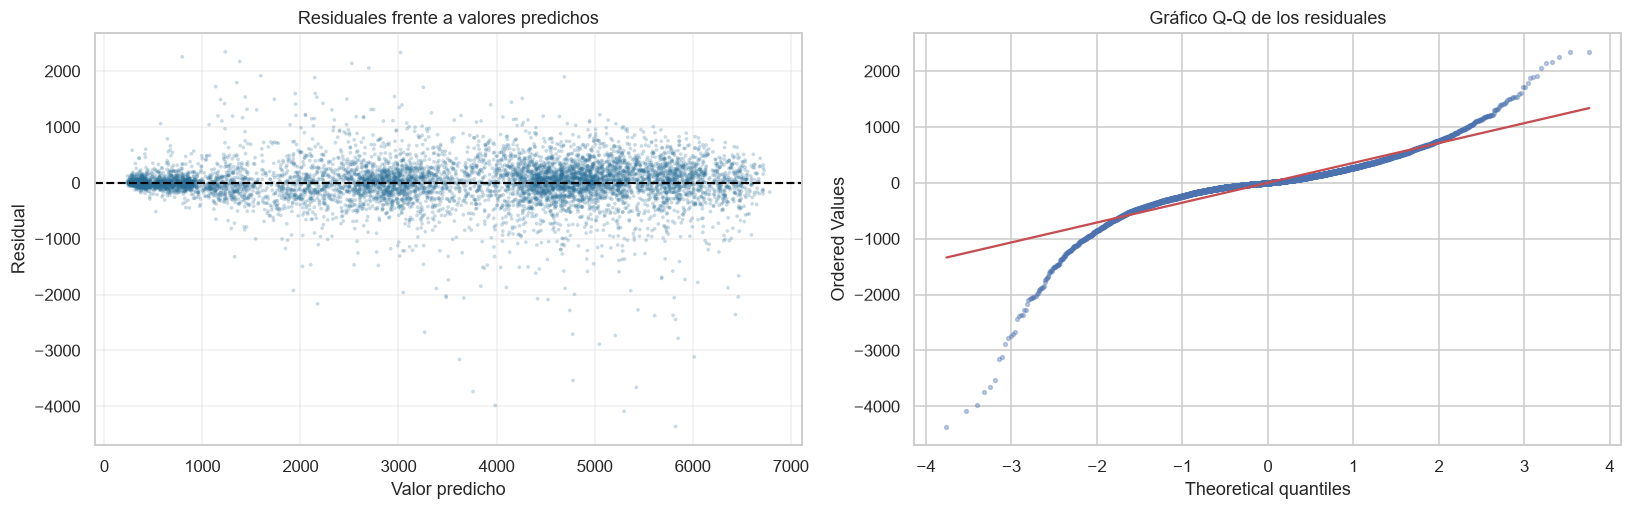

In [47]:
# 3. Diagnóstico complementario: residuales contra predicciones y gráfico Q-Q
fig, ax = plt.subplots(1, 2, figsize=(15, 4.8))
ax[0].scatter(mejor_pred, residuales, s=6, alpha=0.25, color=AZUL, edgecolors='none')
ax[0].axhline(0, ls='--', color='black', lw=1.4)
ax[0].set_xlabel('Valor predicho')
ax[0].set_ylabel('Residual')
ax[0].set_title('Residuales frente a valores predichos')
ax[0].grid(alpha=0.3)

stats.probplot(residuales, dist='norm', plot=ax[1])
ax[1].set_title('Gráfico Q-Q de los residuales')
ax[1].get_lines()[0].set_markersize(2.5)
ax[1].get_lines()[0].set_alpha(0.35)

plt.tight_layout()
plt.savefig('figures/fig15_diagnostico_residuales.png', dpi=150, bbox_inches='tight')
plt.show()

### 6. Interpretación y conclusiones

**6.1 Selección del mejor modelo**

Se selecciona el **Random Forest** con 300 árboles, profundidad máxima 20 y un mínimo de
10 muestras para dividir un nodo.

*Métrica principal.* El RMSE sobre test es de **385,74 vehículos por hora**, frente a
1.766,16 de Ridge y 1.979,33 del baseline. El error del bosque es un 78,2% menor que el
del modelo penalizado y un 80,5% menor que el de predecir siempre la media. Llevado al
dominio del problema, el modelo se equivoca en promedio en 238 vehículos por hora, medido
como MAE, sobre un flujo medio de 3.306 vehículos, lo que equivale a un error del 7,2%.
El R2 de 0,9620 indica que explica el 96,2% de la varianza del tráfico horario.

*Comparación entre train y test.* El R2 de entrenamiento es 0,9825 y el de test 0,9620,
con una brecha de **0,0205**. Es una diferencia pequeña, esperable en un ensamble de
árboles y muy inferior a la que se observaría con un bosque sin restricciones de
profundidad, donde el R2 de entrenamiento supera 0,99. Los límites `max_depth=20` y
`min_samples_split=10` que eligió la validación cruzada cumplieron su función de control,
de modo que **no hay sobreajuste relevante**. Ridge, en cambio, presenta una brecha de
apenas 0,0008, pero por la razón opuesta: no sobreajusta porque tampoco aprende, ya que
subajusta el problema por completo.

*Compromiso entre desempeño e interpretabilidad.* Ridge es un modelo directamente
legible, con 56 coeficientes que indican magnitud y signo, mientras que el Random Forest
requiere métodos indirectos como la reducción media de impureza. Sin embargo, la
diferencia de desempeño es demasiado grande para pagarla a cambio de interpretabilidad:
Ridge explica un 20,4% de la varianza contra un 96,2% del bosque. Un modelo interpretable
que se equivoca por 1.766 vehículos por hora no es útil para operar. Además, como muestra
el anexo 6.5, la desventaja de Ridge no proviene de su naturaleza lineal sino de la
codificación ordinal que la ficha prescribe para `hour`, y la importancia de variables
del bosque resultó perfectamente interpretable.

*Tiempo de inferencia.* El bosque predice las 8.115 observaciones de test en 0,2658
segundos, es decir 33 microsegundos por predicción, frente a 0,0013 segundos de Ridge. El
entrenamiento toma 21,79 segundos contra 0,0098 de Ridge. Aunque el bosque es tres
órdenes de magnitud más lento, el costo absoluto es irrelevante para un problema que
requiere una predicción por hora, y el reentrenamiento periódico en menos de medio minuto
es perfectamente operable.

**6.2 Importancia de las variables**

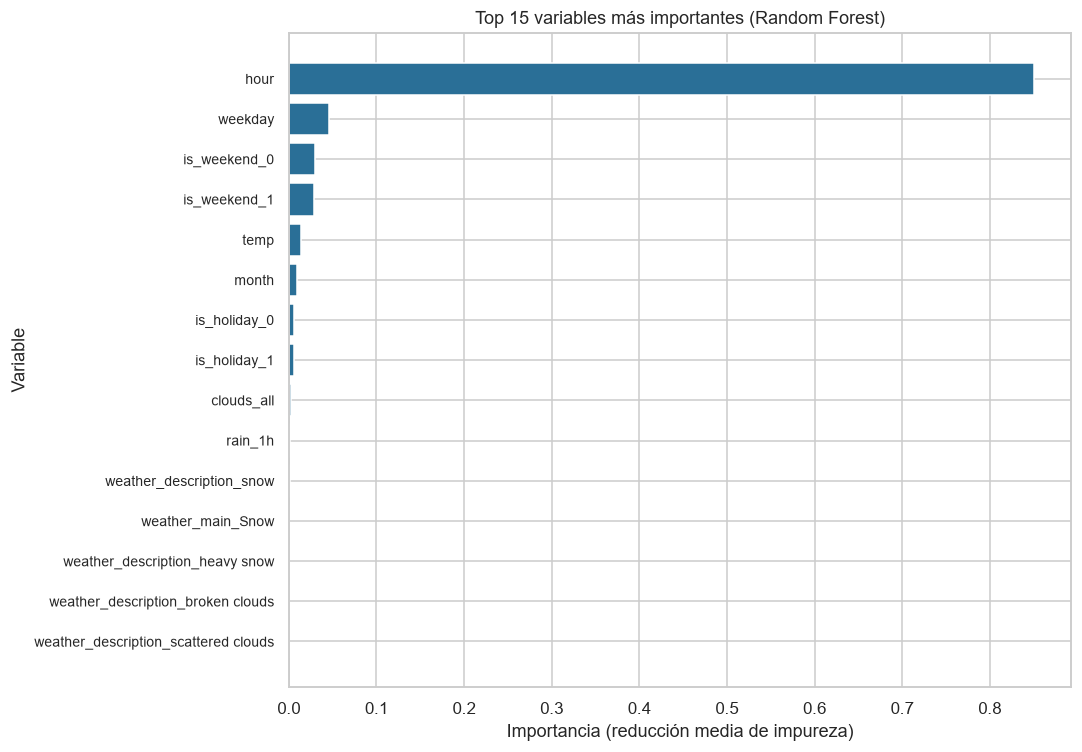

Top 10 variables por importancia:
ordinales__hour            0.8506
ordinales__weekday         0.0454
nominales__is_weekend_0    0.0304
nominales__is_weekend_1    0.0289
continuas__temp            0.0142
ordinales__month           0.0089
nominales__is_holiday_0    0.0060
nominales__is_holiday_1    0.0060
continuas__clouds_all      0.0023
continuas__rain_1h         0.0009
dtype: float64

Las cinco primeras concentran el 96.95% de la importancia total


In [48]:
# 1. Extraer la importancia de variables del mejor modelo
importancias = pd.Series(mejor_modelo.feature_importances_,
                         index=feat_names).sort_values(ascending=False)

# 2. Graficar las 15 variables más importantes
top15 = importancias.head(15)[::-1]
plt.figure(figsize=(10, 7))
plt.barh(range(len(top15)), top15.values, color=AZUL)
plt.yticks(range(len(top15)), [t.split('__')[-1] for t in top15.index], fontsize=9)
plt.xlabel('Importancia (reducción media de impureza)')
plt.ylabel('Variable')
plt.title(f'Top 15 variables más importantes ({mejor_nombre})')
plt.tight_layout()
plt.savefig('figures/fig16_importancia_variables.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 10 variables por importancia:")
print(importancias.head(10).round(4))
print(f"\nLas cinco primeras concentran el {importancias.head(5).sum():.2%} de la importancia total")

In [49]:
# 3. Contrastar la importancia del modelo con la correlación lineal del EDA
tabla_contraste = pd.DataFrame(
    {'importancia_RF': importancias.head(8).round(4).values},
    index=[t.split('__')[-1] for t in importancias.head(8).index])
tabla_contraste['correlacion_Pearson_EDA'] = [
    round(corr_objetivo[v], 4) if v in corr_objetivo.index else 'no aplica'
    for v in tabla_contraste.index]
print("Importancia del modelo frente a la correlación lineal medida en el EDA:")
print(tabla_contraste.to_string())

Importancia del modelo frente a la correlación lineal medida en el EDA:
              importancia_RF correlacion_Pearson_EDA
hour                  0.8506                  0.3552
weekday               0.0454                 -0.1445
is_weekend_0          0.0304               no aplica
is_weekend_1          0.0289               no aplica
temp                  0.0142                  0.1393
month                 0.0089                 -0.0045
is_holiday_0          0.0060               no aplica
is_holiday_1          0.0060               no aplica


**6.3 Interpretación de las variables en lenguaje de negocio**

Las cinco variables más importantes concentran el **96,95%** de la capacidad predictiva
del modelo.

1. **`hour`, con 0,8506 de importancia.** La hora del día explica por sí sola el 85% de
   la predicción. El tráfico pasa de 373 vehículos a las 3 de la madrugada a 5.709 a las
   16 horas, una variación de quince veces. Para un operador vial esto significa que
   conocer la hora es casi todo lo que se necesita para anticipar la carga de la
   autopista.
2. **`weekday`, con 0,0454.** El día de la semana es el segundo factor. Ordena la
   demanda entre los días hábiles y marca la caída del fin de semana.
3. **`is_weekend`, con 0,0593 al sumar sus dos categorías.** Separar el fin de semana del
   resto aporta más que `weekday` por sí sola. El perfil de clusters lo cuantifica: 2.679
   vehículos por hora en fin de semana contra cerca de 3.500 en días laborales, una caída
   del 23%.
4. **`temp`, con 0,0142.** La temperatura entra como una señal estacional débil. No es que
   el frío detenga a los conductores, sino que actúa como sustituto de la época del año.
5. **`month`, con 0,0089.** Confirma el efecto estacional, de menor magnitud.

El contraste con el EDA es el resultado más instructivo de esta sección. La correlación
de Pearson entre `hour` y el tráfico era de apenas **0,355**, un valor que en una lectura
apresurada habría llevado a descartar la variable por débil. El modelo le asigna el 85%
de la importancia. La discrepancia no es un error de ninguno de los dos: Pearson mide
asociación lineal, y la relación entre hora y tráfico es una curva que sube hasta las 16
horas y luego baja, de modo que un coeficiente lineal único no puede capturarla. La
lección práctica es que **una correlación baja no autoriza a descartar una variable**
cuando la relación puede ser no monótona.

En sentido inverso, el clima resultó tan irrelevante como anticipaba el EDA. `clouds_all`
aporta 0,0023 de importancia y `rain_1h` apenas 0,0009. Las personas se desplazan a
trabajar con lluvia o sin ella, y la demanda de esta autopista es esencialmente
inelástica al clima.

**6.4 Análisis de las observaciones con mayor error**

In [50]:
# 1. Identificar las diez observaciones con mayor error absoluto
analisis_error = X_test.copy()
analisis_error['real'] = y_test.values
analisis_error['predicho'] = mejor_pred
analisis_error['residual'] = analisis_error['real'] - analisis_error['predicho']
analisis_error['error_abs'] = analisis_error['residual'].abs()

peores = analisis_error.nlargest(10, 'error_abs')
print("Diez observaciones con mayor error absoluto:")
print(peores[['hour', 'weekday', 'month', 'is_weekend', 'is_holiday', 'temp',
              'weather_main', 'real', 'predicho', 'residual']].round(2).to_string())

Diez observaciones con mayor error absoluto:
       hour  weekday  month  is_weekend  is_holiday   temp  weather_main  real  predicho  residual
13205     7        4      7           0           0  16.06         Clear  1464   5825.15  -4361.15
13204     6        4      7           0           0  13.95          Mist  1212   5300.50  -4088.50
21499    10        5      7           1           0  25.97  Thunderstorm     3   3986.20  -3983.20
21524    11        6      7           1           0  26.30        Clouds    24   3760.57  -3736.57
13206     8        4      7           0           0  18.46        Clouds  1766   5425.65  -3659.65
10591    11        4      2           0           0 -12.76        Clouds  1244   4780.33  -3536.33
21523    10        6      7           1           0  25.49        Clouds   463   3623.46  -3160.46
13214    16        4      7           0           0  24.81        Clouds  2902   6017.36  -3115.36
33406     8        1     12           0           0  -8.43      

In [51]:
# 2. Comparar el perfil de esas diez observaciones con el resto del conjunto de test
resto = analisis_error.drop(peores.index)
comparacion_error = pd.DataFrame({
    'diez_peores': {'error_absoluto_medio': round(peores['error_abs'].mean(), 1),
                    'trafico_real_medio': round(peores['real'].mean(), 1),
                    'hora_media': round(peores['hour'].mean(), 1),
                    'pct_fin_de_semana': round(peores['is_weekend'].mean() * 100, 1),
                    'pct_feriado': round(peores['is_holiday'].mean() * 100, 1),
                    'temperatura_media': round(peores['temp'].mean(), 1)},
    'resto_del_test': {'error_absoluto_medio': round(resto['error_abs'].mean(), 1),
                       'trafico_real_medio': round(resto['real'].mean(), 1),
                       'hora_media': round(resto['hour'].mean(), 1),
                       'pct_fin_de_semana': round(resto['is_weekend'].mean() * 100, 1),
                       'pct_feriado': round(resto['is_holiday'].mean() * 100, 1),
                       'temperatura_media': round(resto['temp'].mean(), 1)}})
print(comparacion_error.to_string())

print("\nDistribución horaria de los diez peores errores:")
print(peores['hour'].value_counts().sort_index().to_string())

                      diez_peores  resto_del_test
error_absoluto_medio       3531.2           233.5
trafico_real_medio         1430.7          3305.8
hora_media                    9.5            11.5
pct_fin_de_semana            30.0            29.1
pct_feriado                   0.0             2.9
temperatura_media            13.0             8.3

Distribución horaria de los diez peores errores:
hour
6     1
7     1
8     3
10    2
11    2
16    1


**Interpretación de los errores más grandes**

Los diez peores casos comparten tres rasgos y ninguno es casual.

*Todos son sobrepredicciones.* Los diez residuales son negativos, con un error absoluto
medio de **3.531 vehículos por hora** contra 233,5 del resto del test, es decir quince
veces mayor. En todos los casos el modelo esperaba tráfico alto y el flujo real fue muy
bajo: el tráfico real medio de este grupo es de 1.430,7 vehículos frente a 3.305,8 del
resto.

*Se concentran en horas de alta demanda esperada.* Cinco de los diez ocurren entre las 6
y las 8 de la mañana y cuatro entre las 10 y las 11, que son precisamente las franjas
donde el modelo predice con más confianza valores elevados. El error no aparece en la
madrugada, donde el tráfico es bajo y estable.

*Llegan en rachas consecutivas, no aislados.* Los registros de las horas 6, 7 y 8
corresponden al mismo viernes de julio, y los de las horas 10 y 11 a dos fines de semana
del mismo mes. El caso más extremo es un domingo a las 10 de la mañana con **3 vehículos
reales frente a 3.986 predichos**.

La conclusión es que estos no son errores del modelo sino **eventos que el modelo no
puede conocer**: cortes de vía por obras, cierres por accidente o fallas del sensor de
conteo. Un flujo de 3 vehículos en una hora de un domingo de julio en una autopista
interestatal no es un dato de tráfico bajo, es una vía cerrada. Ninguna variable del
dataset informa sobre incidentes o trabajos programados, de modo que el modelo predice
correctamente el comportamiento normal y falla justamente cuando la normalidad se
interrumpe. Es una limitación de los datos disponibles y no del algoritmo.

**6.5 Anexo: por qué Ridge queda tan por debajo del Random Forest**

El punto 11 de la ficha prescribe tratar `hour` con `OrdinalEncoder`, lo que la convierte
en un número de 0 a 23 y obliga al modelo lineal a asignarle **un único coeficiente**.
Pero el tráfico sube desde las 3 de la madrugada hasta las 16 horas y luego desciende, de
modo que la relación no es monótona y ningún coeficiente único puede representarla.

El siguiente experimento aísla ese efecto. Se usa el mismo modelo, los mismos datos y la
misma semilla, y lo único que cambia es la codificación de la hora.

In [52]:
# 1. Construir un preprocesador alternativo donde 'hour' se trata como nominal
prep_alternativo = crear_preprocesador(continuas=CONTINUAS,
                                       ordinales=['weekday', 'month'],
                                       nominales=NOMINALES + ['hour'])
X_train_alt = prep_alternativo.fit_transform(X_train)
X_test_alt = prep_alternativo.transform(X_test)

# 2. Ajustar el mismo Ridge con el alpha óptimo ya encontrado
ridge_alt = Ridge(alpha=gs_ridge.best_params_['alpha'], random_state=SEED)
ridge_alt.fit(X_train_alt, y_train)
pred_alt = ridge_alt.predict(X_test_alt)

r2_ordinal = r2_score(y_test, predicciones['Ridge (L2)'])
r2_onehot = r2_score(y_test, pred_alt)
rmse_ordinal = np.sqrt(mean_squared_error(y_test, predicciones['Ridge (L2)']))
rmse_onehot = np.sqrt(mean_squared_error(y_test, pred_alt))

print(f"Ridge con 'hour' ordinal, que es lo que prescribe la ficha:")
print(f"    R2 = {r2_ordinal:.4f} | RMSE = {rmse_ordinal:.4f} | {X_train_prep.shape[1]} variables")
print(f"Ridge con 'hour' en one-hot, cambiando solo la codificación:")
print(f"    R2 = {r2_onehot:.4f} | RMSE = {rmse_onehot:.4f} | {X_train_alt.shape[1]} variables")
print(f"\nGanancia en R2: {r2_onehot - r2_ordinal:+.4f}")
print(f"Reducción del RMSE: {rmse_ordinal - rmse_onehot:.1f} vehículos por hora")

Ridge con 'hour' ordinal, que es lo que prescribe la ficha:
    R2 = 0.2037 | RMSE = 1766.1594 | 56 variables
Ridge con 'hour' en one-hot, cambiando solo la codificación:
    R2 = 0.8331 | RMSE = 808.4924 | 79 variables

Ganancia en R2: +0.6294
Reducción del RMSE: 957.7 vehículos por hora


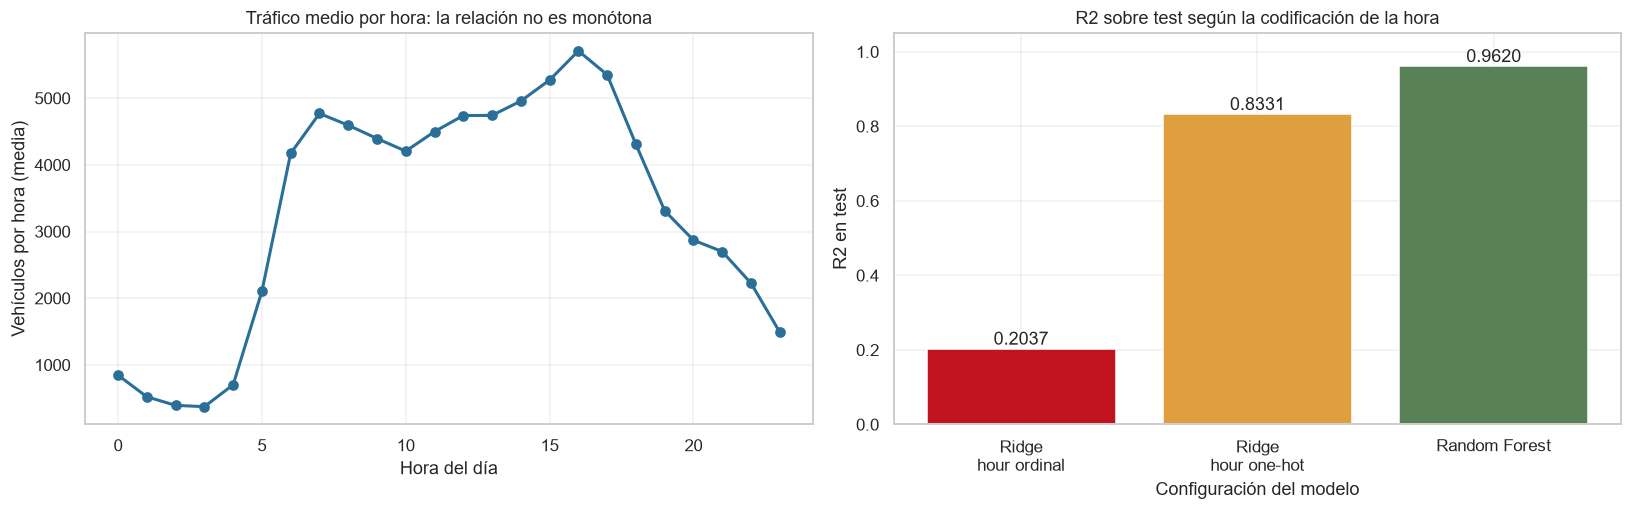

In [53]:
# 3. Mostrar la relación no monótona y el efecto de la codificación sobre el R2
fig, ax = plt.subplots(1, 2, figsize=(15, 4.8))
medias_hora = df.groupby('hour')['traffic_volume'].mean()
ax[0].plot(medias_hora.index, medias_hora.values, marker='o', color=AZUL, lw=2)
ax[0].set_title('Tráfico medio por hora: la relación no es monótona')
ax[0].set_xlabel('Hora del día')
ax[0].set_ylabel('Vehículos por hora (media)')
ax[0].grid(alpha=0.3)

nombres_barras = ['Ridge\nhour ordinal', 'Ridge\nhour one-hot', 'Random Forest']
r2_rf = tabla_comparativa.loc[tabla_comparativa['Modelo'] == 'Random Forest', 'R2 test'].iloc[0]
barras = ax[1].bar(nombres_barras, [r2_ordinal, r2_onehot, r2_rf],
                   color=[ROJO, '#e09f3e', VERDE])
ax[1].bar_label(barras, fmt='%.4f')
ax[1].set_ylim(0, 1.05)
ax[1].set_title('R2 sobre test según la codificación de la hora')
ax[1].set_xlabel('Configuración del modelo')
ax[1].set_ylabel('R2 en test')
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figures/fig17_experimento_codificacion.png', dpi=150, bbox_inches='tight')
plt.show()

### 7. Conclusiones ejecutivas

**Hallazgos del análisis exploratorio.** El trabajo con este dataset estuvo determinado
por tres problemas de calidad de datos que no eran visibles a primera vista. Primero, los
48.143 valores faltantes que pandas reportaba en `holiday` resultaron ser un artefacto de
lectura, ya que la columna usa el texto literal `"None"` como categoría y el dataset en
realidad no tiene ningún nulo. Segundo, 7.629 marcas temporales estaban duplicadas porque
la fuente escribe una fila por condición meteorológica simultánea, lo que habría
introducido las mismas horas en train y en test. Tercero, once registros contenían
valores físicamente imposibles, como una temperatura de 0 Kelvin y una precipitación de
9.831 milímetros en una hora. El hallazgo con mayor consecuencia fue, sin embargo, que
las variables meteorológicas casi no correlacionan con el tráfico, mientras que el
volumen varía quince veces a lo largo del día. Toda la señal estaba en `date_time` y hubo
que extraerla mediante ingeniería de variables.

**Patrones del análisis no supervisado.** PCA requirió 7 componentes para explicar el
85,65% de la varianza de las 56 variables preprocesadas. K-Means entregó primero un
resultado degenerado, con un cluster de 9 observaciones, cuya causa fue `snow_1h`: al ser
cero en el 99,92% de los registros, su estandarización generó puntos situados a 83
desviaciones estándar del centro. Corregido ese defecto, K = 4 produjo grupos
equilibrados que se organizan por **estación del año, nubosidad y tipo de día**, con el
fin de semana claramente separado y con 2.679 vehículos por hora frente a cerca de 3.500
de los días laborales. El resultado más valioso es negativo: la segmentación **no**
recuperó los regímenes horarios, porque la hora media es casi idéntica en los cuatro
grupos. Los métodos no supervisados encuentran la estructura que domina la varianza, que
aquí es meteorológica, y no necesariamente la que importa para predecir.

**Modelo seleccionado.** El Random Forest alcanza un RMSE de 385,74 vehículos por hora y
un R2 de 0,9620 sobre test, contra 1.766,16 y 0,2037 de Ridge. La brecha de R2 entre
train y test es de 0,0205, de modo que no hay sobreajuste relevante. Se elige por
desempeño: la diferencia con el modelo lineal es demasiado grande para intercambiarla por
interpretabilidad.

**Las tres variables principales.** La hora del día concentra el 85,06% de la importancia
y es prácticamente el fenómeno completo. El día de la semana aporta 4,54% y la condición
de fin de semana un 5,93% adicional, capturando juntas la caída del 23% en el flujo de
sábado y domingo. La temperatura, con 1,42%, opera como sustituto de la estación del año
más que como factor causal del comportamiento de los conductores.

**Limitaciones.** Primera, el dataset tiene un vacío de 307 días entre agosto de 2014 y
junio de 2015, de modo que la cobertura temporal es discontinua y cualquier tendencia
interanual queda mal estimada. Segunda, la partición se hizo de forma aleatoria y no
cronológica, lo que significa que el modelo pudo usar horas posteriores para predecir
horas anteriores; el R2 de 0,9620 es por lo tanto optimista respecto de lo que se
obtendría prediciendo el futuro real. Tercera, no existe ninguna variable sobre
incidentes, obras o cierres de vía, que son exactamente la causa de los diez errores más
grandes. Cuarta, los datos provienen de una única estación de conteo en un solo sentido
de la autopista, así que las conclusiones no son extrapolables a otros tramos.

**Recomendaciones.** La primera es operativa: dado que la hora y el tipo de día explican
más del 90% del comportamiento, la planificación de personal, de mantenimiento vial y de
señalización dinámica puede construirse sobre un calendario de demanda por franja horaria
y día de la semana, sin necesidad de incorporar pronóstico meteorológico, cuyo aporte
resultó marginal. La segunda es metodológica: si el modelo se va a usar para predecir
tráfico futuro, la partición debe rehacerse de forma cronológica, entrenando con los
primeros años y evaluando con el último, y hay que esperar un desempeño menor al reportado
aquí.

**Trabajo futuro.** La línea con mayor potencial es incorporar una fuente externa de
incidentes viales, por ejemplo los reportes del Departamento de Transporte de Minnesota,
y tratar el problema como una serie temporal con validación cruzada de ventana
deslizante. Eso permitiría atacar simultáneamente las dos limitaciones más serias del
trabajo actual, que son la ausencia de información sobre eventos y el carácter optimista
de la partición aleatoria.